# Loading libraries and Data

In [ ]:
import nltk
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('wordnet')
!pip install lingua-language-detector
!pip install scapy
!pip install langdetect
!pip install transformers
!pip install sentencepiece
!pip install deep-translator

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 4.6 MB/s eta 0:00:00


In [ ]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import torch
import spacy
from transformers import pipeline
from tqdm.auto import tqdm
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob
from transformers import pipeline
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException
from transformers import MarianMTModel, MarianTokenizer
from lingua import Language, LanguageDetectorBuilder
from deep_translator import GoogleTranslator
import warnings
warnings.filterwarnings('ignore')

In [ ]:
client = bigquery.Client()
query = """
SELECT *
FROM `cs163-project-487801.amazon_digital_devices_cleaned.digital_devices_reviews_no_duplicates`
"""

df = client.query(query).to_dataframe()

In [ ]:
reviews = df[df['main_category'] != 'Office Products'].copy()

In [ ]:
exclude_ids = ["B00I8C5ENU", "B01DA4V074", "B072BYCRNF", "B07PDSTG9C", "B07FSMS62P",
               "B089QJZ54T", "B07QYRQTYJ", "B07772JBX1", "B09XHS8485", "B00XZV0WA4",
               "B0043FOOVY", "B004UR9P9Q", "B01N4KVSPA", "B000OKW0IG", "B01K5XFK3I",
               "B00006AMS4", "B0000C9ZJX", "B004575BIU", "B095YFFLVB", "B07855HMW4",
               "B09LR9TLY3", "B074Y7XRB6", "B087YJ1NGC", "B07XCM94SN", "B074PYK939",
               "B01IC2W0IW", "B01B2YLS7G", "B076ZXWVVK", "B016YJWPSK", "B0769G1LGX",
               "B01B2YLQ6E", "B01IC2VY7K", "B01B2YLPLA", "B0713VGCJX", "B071K4L8KL",
               "B000031WCP", "B014VUE4PQ", "B01JIQ6VUE", "B0BWJRHNDD", "B014VY6JFA",
               "B07RYWZJDT", "B0B7QT2KXY", "B083MJ96PL", "B085DBG59V", "B086HCVKQ9",
               "B014VUGIKA", "B07ZT1K1V8", "B00JHAJNO8", 'B07C34CF73']

reviews = reviews[~reviews["parent_asin"].isin(exclude_ids)]

# Data Overview

In [ ]:
# Convert timestamp
reviews["date"] = pd.to_datetime(reviews["timestamp"], unit="ms")
reviews[["timestamp", "date"]].tail()

,timestamp,date
482771,1609273078875,2020-12-29 20:17:58.875
482772,1613157943252,2021-02-12 19:25:43.252
482773,1635350957338,2021-10-27 16:09:17.338
482774,1616330334491,2021-03-21 12:38:54.491
482775,1549939734709,2019-02-12 02:48:54.709


In [ ]:
reviews = reviews.drop(columns=['timestamp','pred_label','rn'])

In [ ]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482776 entries, 0 to 482775
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   parent_asin        482776 non-null  object        
 1   rating             482776 non-null  float64       
 2   review_title       482776 non-null  object        
 3   review_text        482776 non-null  object        
 4   verified_purchase  482776 non-null  boolean       
 5   helpful_vote       482776 non-null  Int64         
 6   product_title      482776 non-null  object        
 7   price              297561 non-null  float64       
 8   average_rating     482776 non-null  float64       
 9   rating_number      482776 non-null  Int64         
 10  main_category      482776 non-null  object        
 11  date               482776 non-null  datetime64[ms]
dtypes: Int64(2), boolean(1), datetime64[ms](1), float64(3), object(5)
memory usage: 42.4+ MB


In [ ]:
reviews.describe()

,rating,helpful_vote,price,average_rating,rating_number,date
count,482776.000000,482776.0,297561.000000,482776.000000,482776.0,482776
mean,3.815471,1.905956,471.314386,4.171512,8085.267279,2020-09-16 14:17:31.529000
min,1.000000,0.0,4.900000,1.000000,1.0,2018-01-01 00:00:05.772000
25%,3.000000,0.0,149.000000,4.000000,89.0,2019-07-09 01:06:07.860000
50%,5.000000,0.0,287.880000,4.300000,467.0,2020-08-27 14:12:33.195000
75%,5.000000,1.0,629.000000,4.400000,2285.0,2021-12-31 00:39:47.328000
max,5.000000,6386.0,8499.990000,5.000000,93357.0,2023-09-09 23:11:31.845000
std,1.575326,20.784035,500.307381,0.404853,22760.690947,NaN


##Distribution of Review Rating

Text(0.5, 0.955, 'Distribution of Review Ratings')

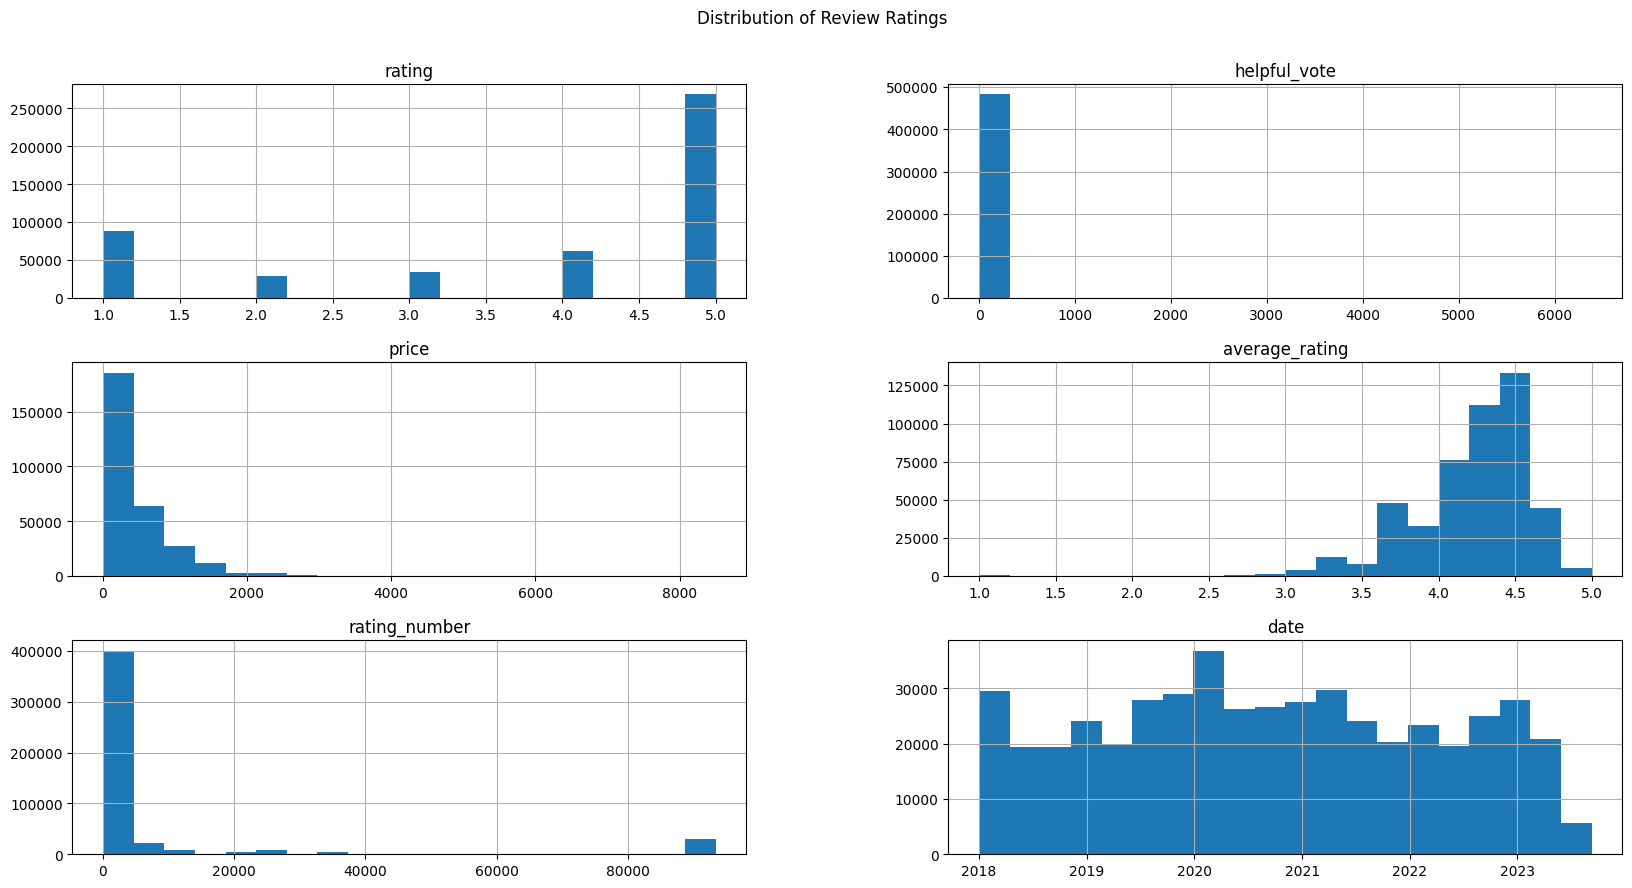

In [ ]:
reviews.hist(figsize=(20,10), bins=20)
plt.suptitle("Distribution of Review Ratings", y=0.955)

### Rating

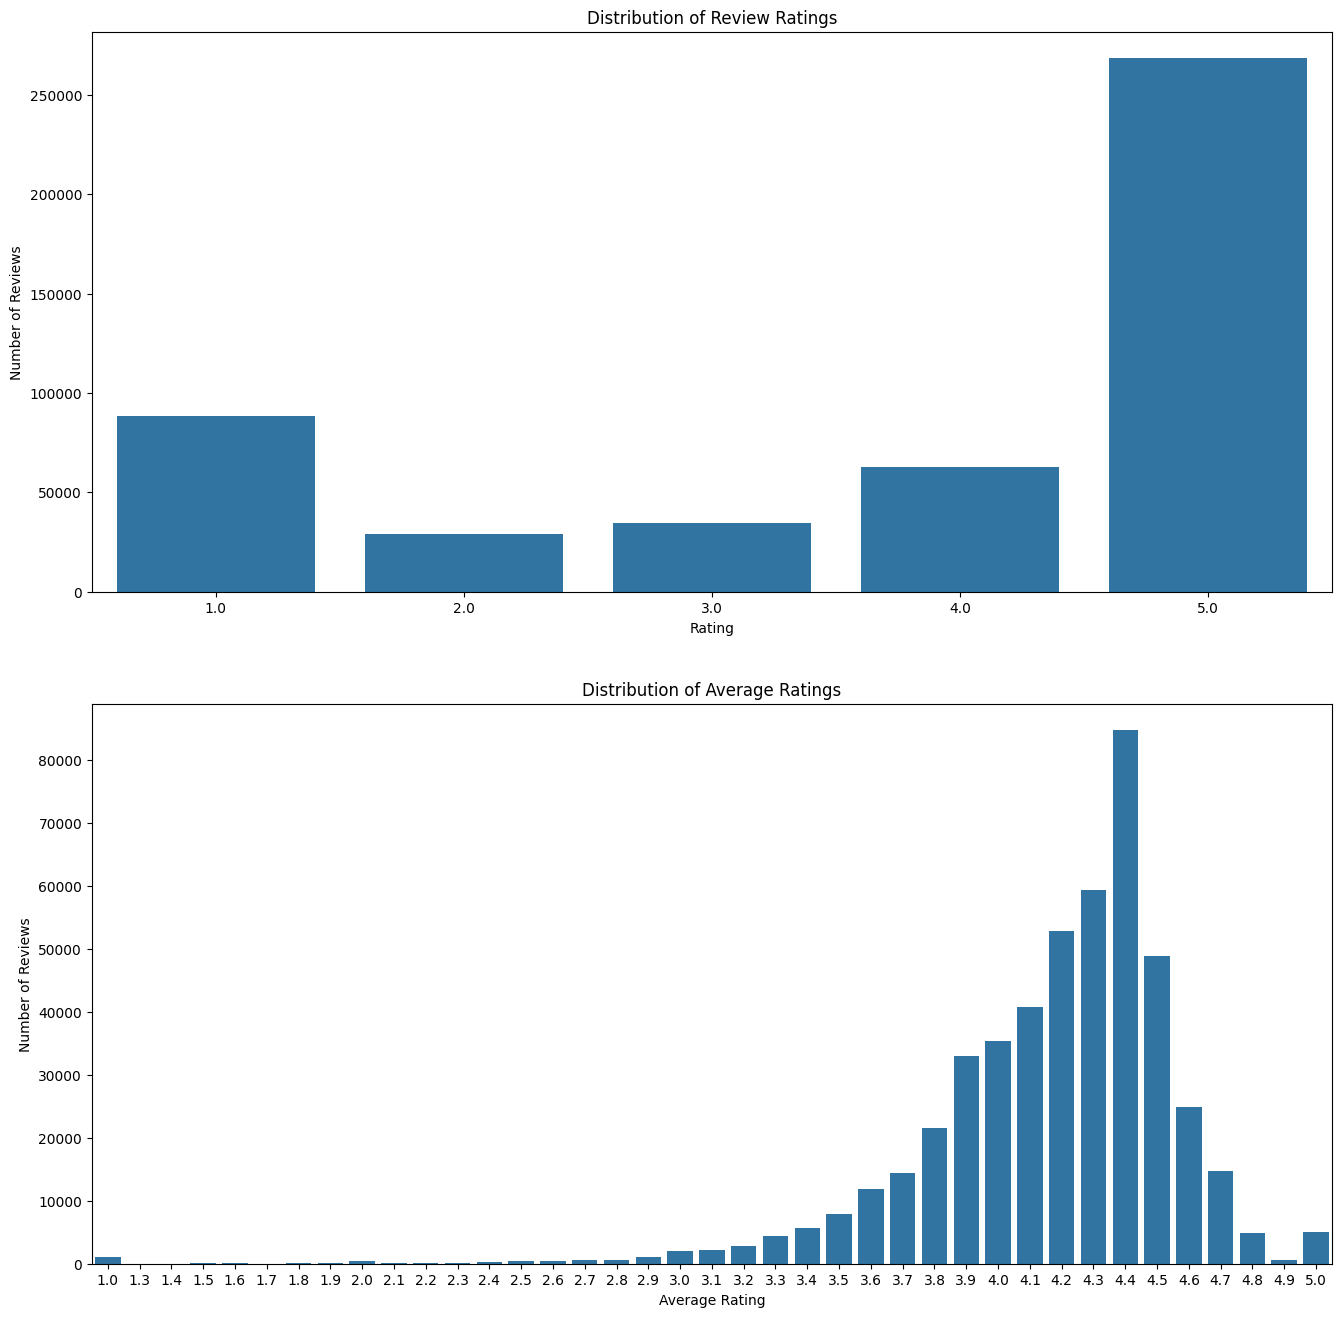

In [ ]:
plt.figure(figsize=(16,16))
plt.subplot(211)
sns.countplot(data=reviews, x="rating")
ax1 = plt.gca()
ax1.set_title("Distribution of Review Ratings")
ax1.set_xlabel("Rating")
ax1.set_ylabel("Number of Reviews")

plt.subplot(212)
sns.countplot(data=reviews, x="average_rating")
ax2 = plt.gca()
ax2.set_title("Distribution of Average Ratings")
ax2.set_xlabel("Average Rating")
ax2.set_ylabel("Number of Reviews")
plt.show()

In [ ]:
reviews['rating_delta'] = reviews['rating'] - reviews['average_rating']

Text(0, 0.5, 'Number of Reviews')

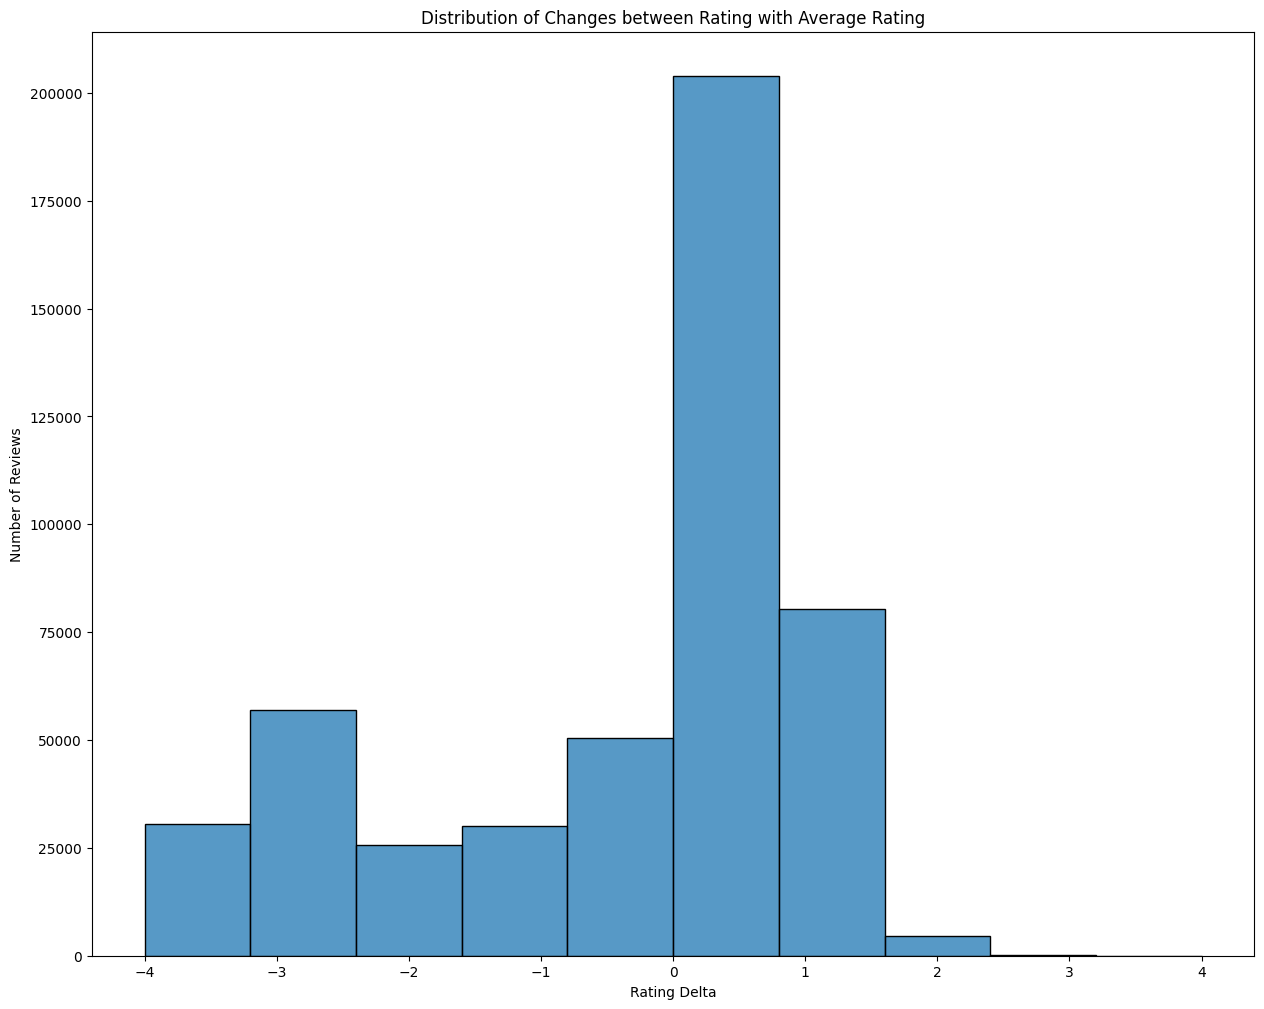

In [ ]:
plt.figure(figsize=(15,12))
sns.histplot(data=reviews, x="rating_delta", bins = 10)
plt.title("Distribution of Changes between Rating with Average Rating")
plt.xlabel("Rating Delta")
plt.ylabel("Number of Reviews")

**Note**: Even though ratings are usually similar (close) with their average_rating, however, there are a noticable amount of negative ratings (ratings on left tail). => worth investing more

(1.0, 5.1)

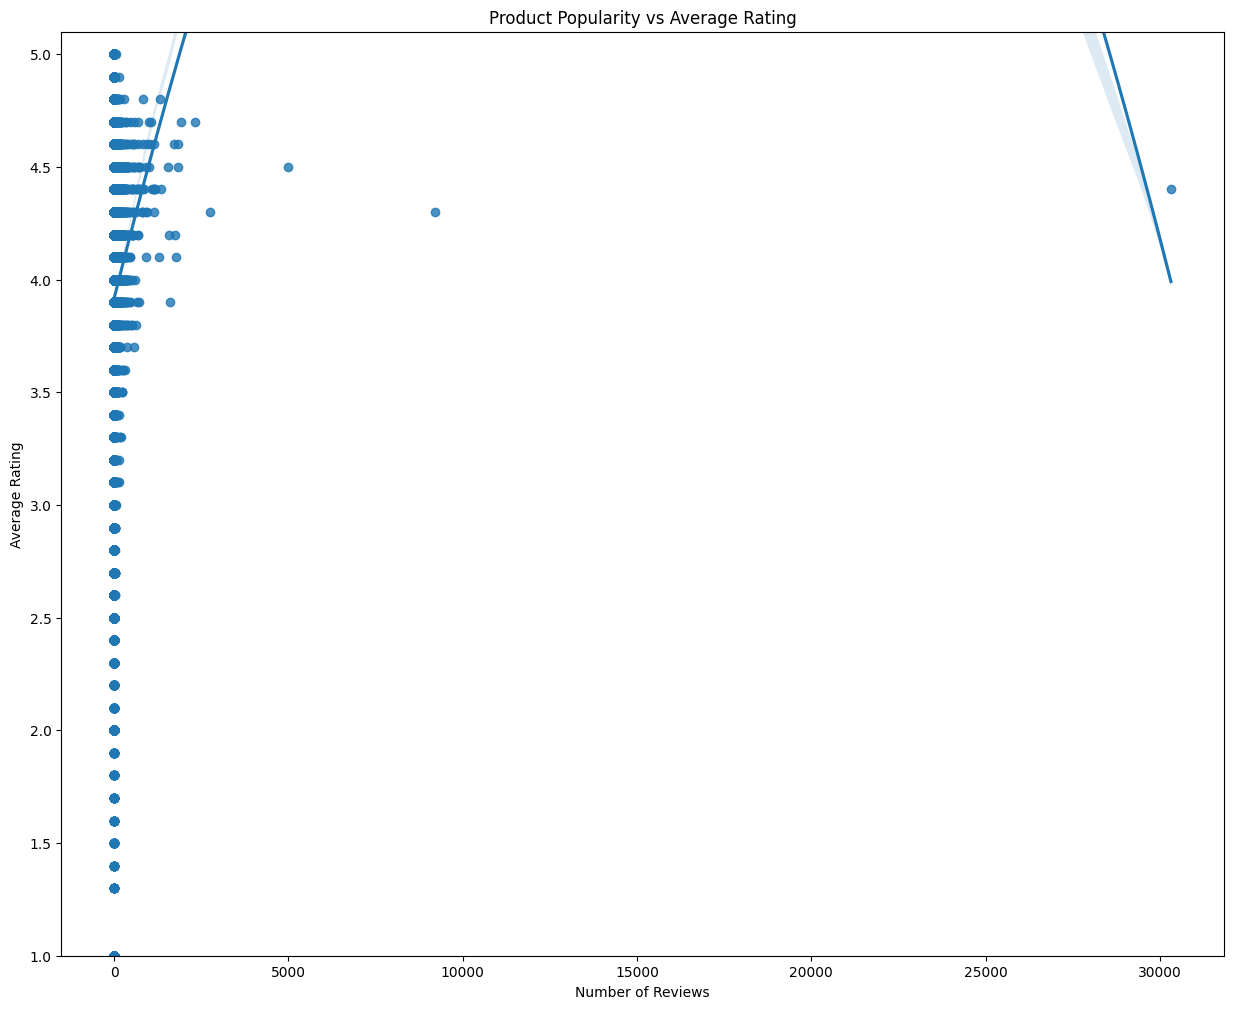

In [ ]:
product_stats = reviews.groupby('parent_asin')['average_rating'].value_counts().reset_index()
product_stats

plt.figure(figsize=(15,12))
sns.regplot(
    data=product_stats,
    x="count",
    y="average_rating",
    ci = 5,
    order=2
)

plt.title("Product Popularity vs Average Rating")
plt.ylabel("Average Rating")
plt.xlabel("Number of Reviews")
plt.ylim(1,5.1)

The regression line slopes slightly upward, suggesting that:Products with more reviews tend to have slightly higher average ratings. However, the trend is weak, meaning popularity does not strongly determine satisfaction.

### Price

**Note**: Since there are many reviews (185215) for products that lost their price (out of production/out of stock/etc). It is better to create a signal (price_missing) to deal with it seperately.

In [ ]:
reviews[reviews["price"].isna()]

,parent_asin,rating,review_title,review_text,verified_purchase,helpful_vote,product_title,price,average_rating,rating_number,main_category,date,rating_delta
0,B06XWPG52Q,1.0,No good,"There is nothing inside, just an empty shell. ...",True,6,*2017* Desktop Computer Intel Kaby Lake 3.6GHz...,NaN,1.0,6,Computers,2021-06-16 23:50:59.756,0.0
1,B06XWPG52Q,1.0,"I received a computer case and not a ""Desktop ...",The title implied I would receive a desktop co...,True,3,*2017* Desktop Computer Intel Kaby Lake 3.6GHz...,NaN,1.0,6,Computers,2022-11-01 19:12:50.103,0.0
2,B09Q2Y7F9Y,1.0,JUNK!!!!!,"JUNK!!!! Do not waste your money, tablets won'...",True,0,"10 inch Android Tablet PC, 1280 * 800 IPS HD D...",NaN,1.0,3,Computers,2022-05-04 20:16:23.194,0.0
3,B09Q2W3FKV,1.0,The item is useless.,Android 9! No longer supported. EOL. Won't ...,True,0,"10 inch Android Tablet PC, 1280 * 800 IPS HD D...",NaN,1.0,1,Computers,2022-04-10 01:17:01.337,0.0
5,B08YDYMYL4,1.0,Look for the red flags,This is not a Dell XPS laptop. Dell does not s...,False,0,"13 7390 Laptop, 13.3"" Touchscreen UHD Infinity...",NaN,1.0,1,Computers,2021-06-22 05:37:05.962,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
482767,B07J4X7GFD,5.0,Amazing PC,This is an amazing product. I did not buy this...,False,0,iBuyPower Pro Gaming PC Computer Desktop Intel...,NaN,5.0,1,Computers,2019-08-23 00:58:51.347,0.0
482768,B08PSG75HZ,5.0,Best purchase of the year.,I love that it is very lightweight. Makes it e...,True,0,jumper 2 in 1 Laptop Jumper x1 Windows 10 Lapt...,NaN,5.0,1,Computers,2021-06-08 04:08:13.425,0.0
482769,B0BL3LHNXG,5.0,Very good laptop,I am very pleased with the performance of this...,True,0,jumper Windows 11 Laptop 13.3 Inch FHD IPS Dis...,NaN,5.0,1,Computers,2023-02-27 00:40:37.963,0.0
482774,B0CDX5VTDM,5.0,Powerful microcomputer,The computer took a week to arrive and was wel...,True,0,"msecore Powerful Mini PC, Core i5-13400F 10 Co...",NaN,5.0,1,Computers,2021-03-21 12:38:54.491,0.0


In [ ]:
reviews["price_missing"] = reviews["price"].isna().astype(int)

#### With price only

In [ ]:
with_price = reviews[reviews['price_missing'] == 0]

Text(0, 0.5, 'Number of Reviews')

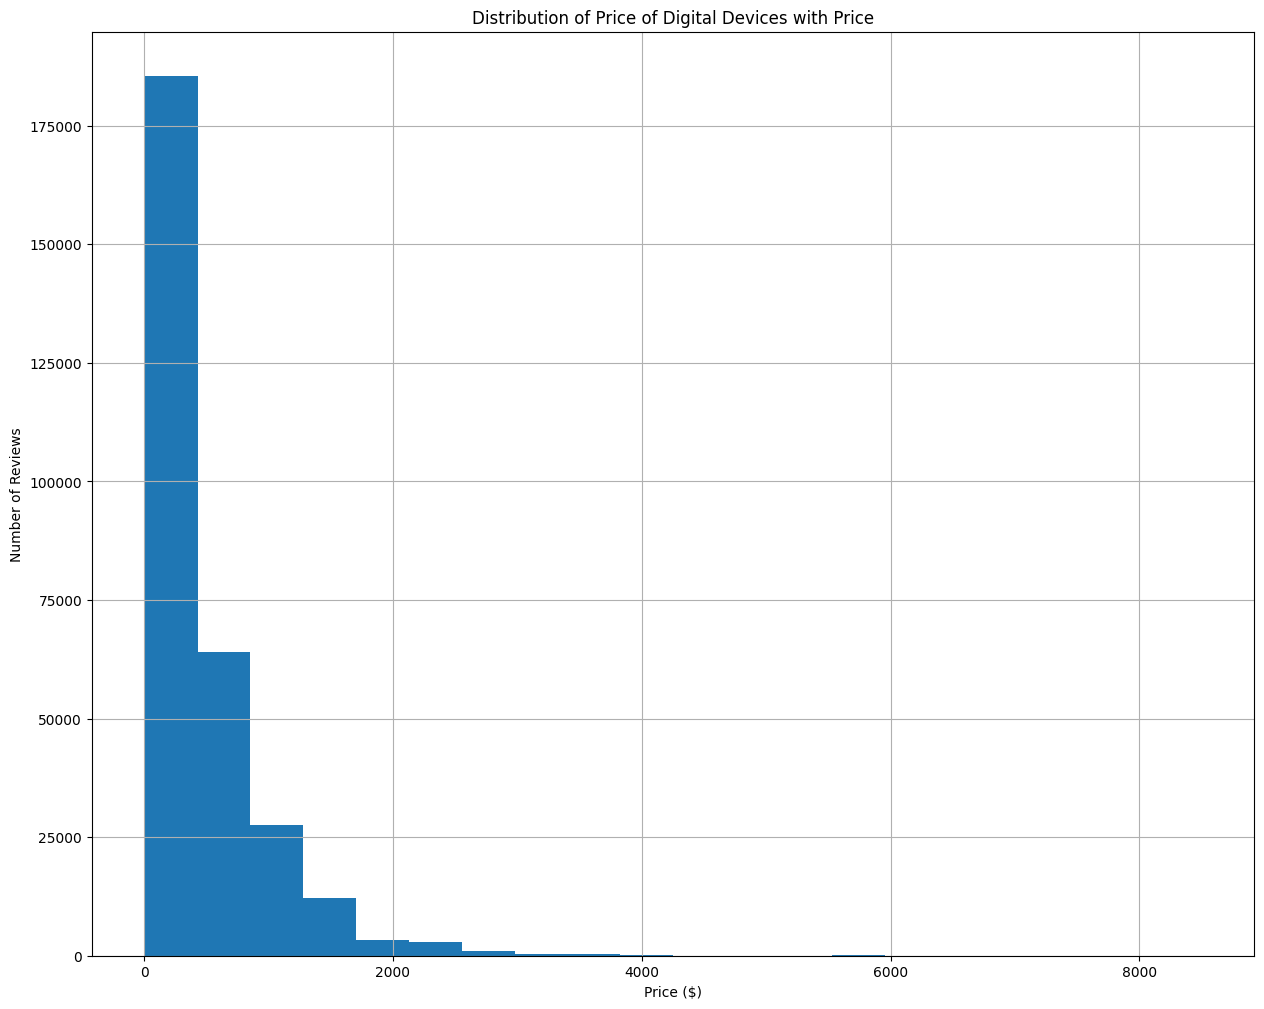

In [ ]:
with_price['price'].hist(figsize=(15,12), bins=20)
plt.title("Distribution of Price of Digital Devices with Price")
plt.xlabel("Price ($)")
plt.ylabel("Number of Reviews")

In [ ]:
with_price.describe()

,rating,helpful_vote,price,average_rating,rating_number,date,rating_delta,price_missing
count,297561.000000,297561.0,297561.000000,297561.000000,297561.0,297561,297561.000000,297561.0
mean,3.826708,2.132517,471.314386,4.216575,2346.408572,2021-02-25 20:52:06.079000,-0.389867,0.0
min,1.000000,0.0,4.900000,1.000000,1.0,2018-01-01 00:50:21.668000,-4.000000,0.0
25%,3.000000,0.0,149.000000,4.000000,139.0,2020-01-17 23:38:16.312000,-1.500000,0.0
50%,5.000000,0.0,287.880000,4.300000,547.0,2021-03-27 18:45:43.609000,0.400000,0.0
75%,5.000000,1.0,629.000000,4.500000,2005.0,2022-06-15 20:44:27.336000,0.700000,0.0
max,5.000000,6386.0,8499.990000,5.000000,35925.0,2023-09-09 04:54:51.035000,4.000000,0.0
std,1.579571,20.584368,500.307381,0.350458,5525.364193,NaN,1.539129,0.0


#### Seperate price tier (using quantile)

In [ ]:
# In this case, I will set prenium price (threshold) as 0.95

quantile = with_price['price'].quantile([0, 0.5, 0.75, 0.975, 1])
display(quantile)

def price_tier(price, quantile):
  if pd.isna(price) or price ==0 :
    return "Unknown"
  elif price >= quantile.loc[0.975]:
    return "Premium"
  elif price > quantile.loc[0.75]:
    return "High"
  elif price > quantile.loc[0.5]:
    return "Medium"
  else :
    return "Low"

with_price['price_tier'] = with_price['price'].apply(lambda x: price_tier(x, quantile))
with_price['price_tier'].value_counts()

,price
0.000,4.90
0.500,287.88
0.750,629.00
0.975,1795.00
1.000,8499.99


/tmp/ipython-input-154/304443551.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  with_price['price_tier'] = with_price['price'].apply(lambda x: price_tier(x, quantile))


,count
price_tier,
Low,148783
Medium,74471
High,66851
Premium,7456


**Note**: With the quantile of 0.95, the highest price product still looks extremely high => Might be outlier but still, we might want to keep it for further investigation

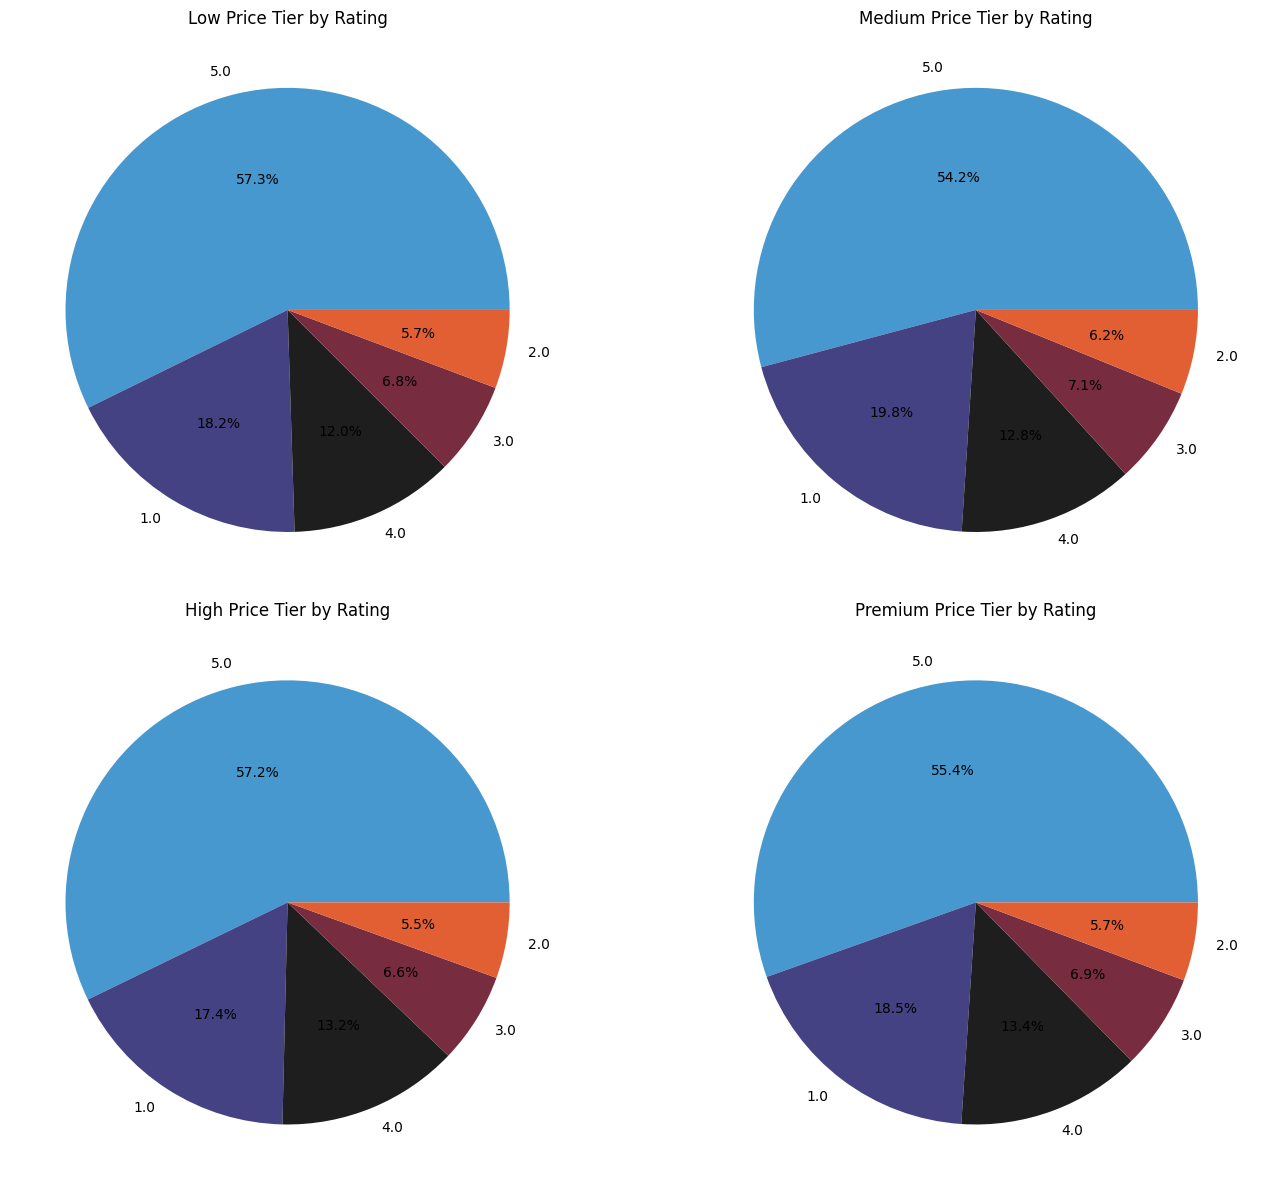

In [ ]:
price_tier_by_rating = with_price.groupby('price_tier')['rating'].value_counts(normalize=True).reset_index()
price_tier_by_rating

low_proportion = price_tier_by_rating[(price_tier_by_rating['price_tier'] == 'Low')]
mid_proportion = price_tier_by_rating[(price_tier_by_rating['price_tier'] == 'Medium')]
high_proportion = price_tier_by_rating[(price_tier_by_rating['price_tier'] == 'High')]
premium_proportion = price_tier_by_rating[(price_tier_by_rating['price_tier'] == 'Premium')]

colors = sns.color_palette("icefire", len(low_proportion))

plt.figure(figsize=(15,12))
plt.subplot(221)
ax1 = plt.gca()
plt.pie(low_proportion['proportion'],
              labels=low_proportion['rating'],
              autopct='%1.1f%%',
        colors = colors)
ax1.set_title("Low Price Tier by Rating")

plt.subplot(222)
ax2 = plt.gca()
plt.pie(mid_proportion['proportion'],
              labels=mid_proportion['rating'],
              autopct='%1.1f%%',
        colors = colors)
ax2.set_title("Medium Price Tier by Rating")

plt.subplot(223)
ax3 = plt.gca()
plt.pie(high_proportion['proportion'],
              labels=high_proportion['rating'],
              autopct='%1.1f%%',
        colors = colors)
ax3.set_title("High Price Tier by Rating")

plt.subplot(224)
ax4 = plt.gca()
plt.pie(premium_proportion['proportion'],
              labels=premium_proportion['rating'],
              autopct='%1.1f%%',
        colors = colors)
ax4.set_title("Premium Price Tier by Rating")

plt.tight_layout()

**Note**: There are no such differences in the distribution of rating by price tier -> Might be harder to find "unique" thing based on distibution

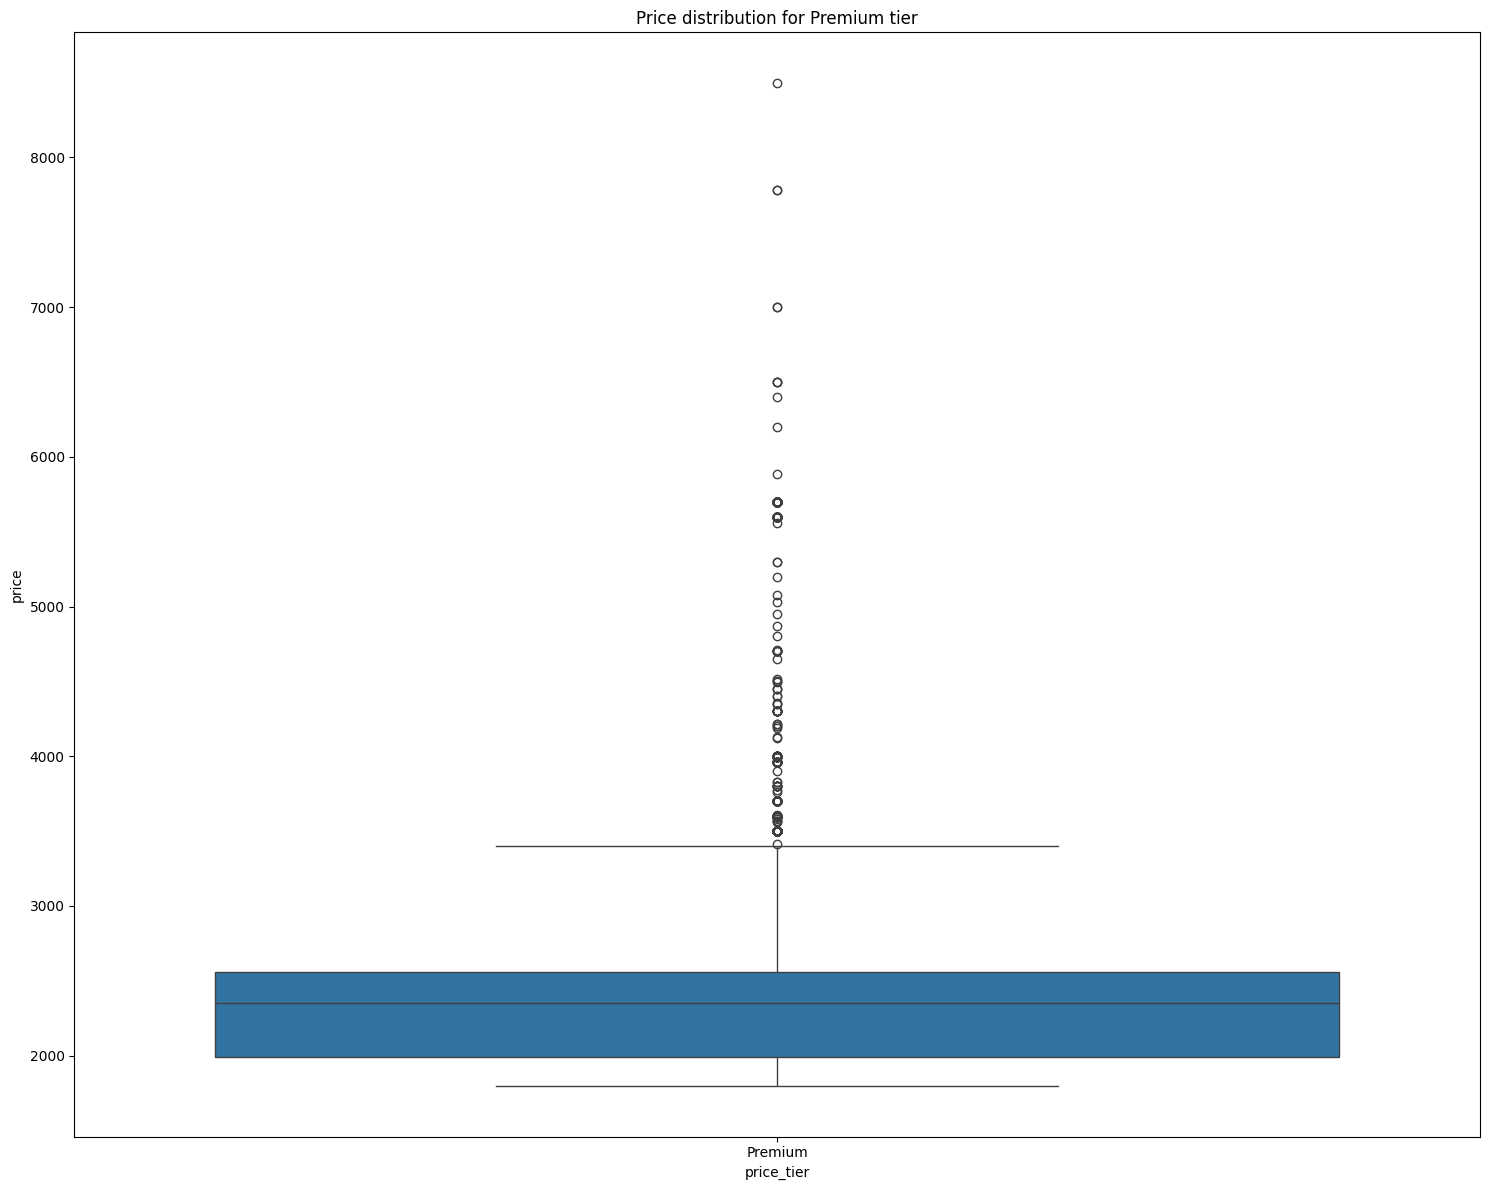

In [ ]:
plt.figure(figsize=(15,12))
sns.boxplot(
    data=with_price[with_price["price_tier"] == "Premium"],
    x="price_tier",
    y="price"
)
plt.title("Price distribution for Premium tier")
plt.tight_layout()

**Note**: We can see "outliers" from here, but to double check

In [ ]:
prem = with_price.loc[with_price["price_tier"] == "Premium", "price"]
q1 = prem.quantile(0.25)
q3 = prem.quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
outliers = with_price[(with_price["price"] > upper_bound)]
outliers

,parent_asin,rating,review_title,review_text,verified_purchase,helpful_vote,product_title,price,average_rating,rating_number,main_category,date,rating_delta,price_missing,price_tier
479,B0BXB6HYSG,1.0,Do not buy this,This was a great laptop for all of 3 days ther...,False,2,HIDevolution [2023] ASUS ROG Zephyrus Duo 16 G...,4519.00,1.0,1,Computers,2023-03-18 20:49:22.801,0.0,0,Premium
779,B08QNG31NQ,1.0,Lenovo support SUCKS,Lenovo sold me a warranty telling me that they...,False,1,Lenovo 2020-2021 ThinkPad P15 Gen 1 - High-End...,4499.00,1.0,1,Computers,2022-08-16 21:38:08.964,0.0,0,Premium
1021,B07K437QQV,1.0,It is trash,It has like 0 fps,False,3,Video Editing Workstation Gaming Desktop Compu...,4499.99,1.0,2,Computers,2021-06-27 18:19:33.858,0.0,0,Premium
1473,B0BHN69FWK,2.0,Not as expected,Arrived without the integrated WiFi/Bluetooth ...,True,0,Dell Precision T3660 Workstation Desktop (2022...,4125.99,2.0,1,Computers,2023-02-21 18:52:18.280,0.0,0,Premium
1487,B09KMJBBYX,3.0,Big design issue,"The performance is exceptional. However, the t...",False,3,"Dell [Windows 11 Home] Newest XPS 9510 Laptop,...",3999.00,2.0,3,Computers,2021-12-12 16:49:10.534,1.0,0,Premium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
481836,B08K3T9Q2D,5.0,"All ThinkPad are amazing, at least for me work...","I bought one used, and it has been the best ch...",False,0,Lenovo ThinkPad P15 Gen 1 - High-End Workstati...,3826.77,5.0,3,Computers,2021-06-19 04:05:00.337,0.0,0,Premium
481876,B071GS48WL,5.0,Best computer I've ever owned.,"I love this computer....fast, powerful and eas...",True,1,Lenovo ThinkPad P71 17.3'' Mobile Workstation ...,3772.99,5.0,1,Computers,2020-08-29 19:55:11.968,0.0,0,Premium
482328,B08BTW12KR,5.0,Most Powerful Laptop I've Ever Had,This laptop is the best laptop I've ever owned...,True,13,"New XPS 17 9710 17.3"" 9700 Laptop 11th Gen Int...",5299.00,5.0,4,Computers,2020-07-13 03:49:11.788,0.0,0,Premium
482329,B08BTW12KR,5.0,Excellent service from Best Notebooks,"Everything works as expected. It is fast, lots...",True,5,"New XPS 17 9710 17.3"" 9700 Laptop 11th Gen Int...",5299.00,5.0,4,Computers,2020-07-20 13:15:49.961,0.0,0,Premium


### Time

Text(0, 0.5, 'Count')

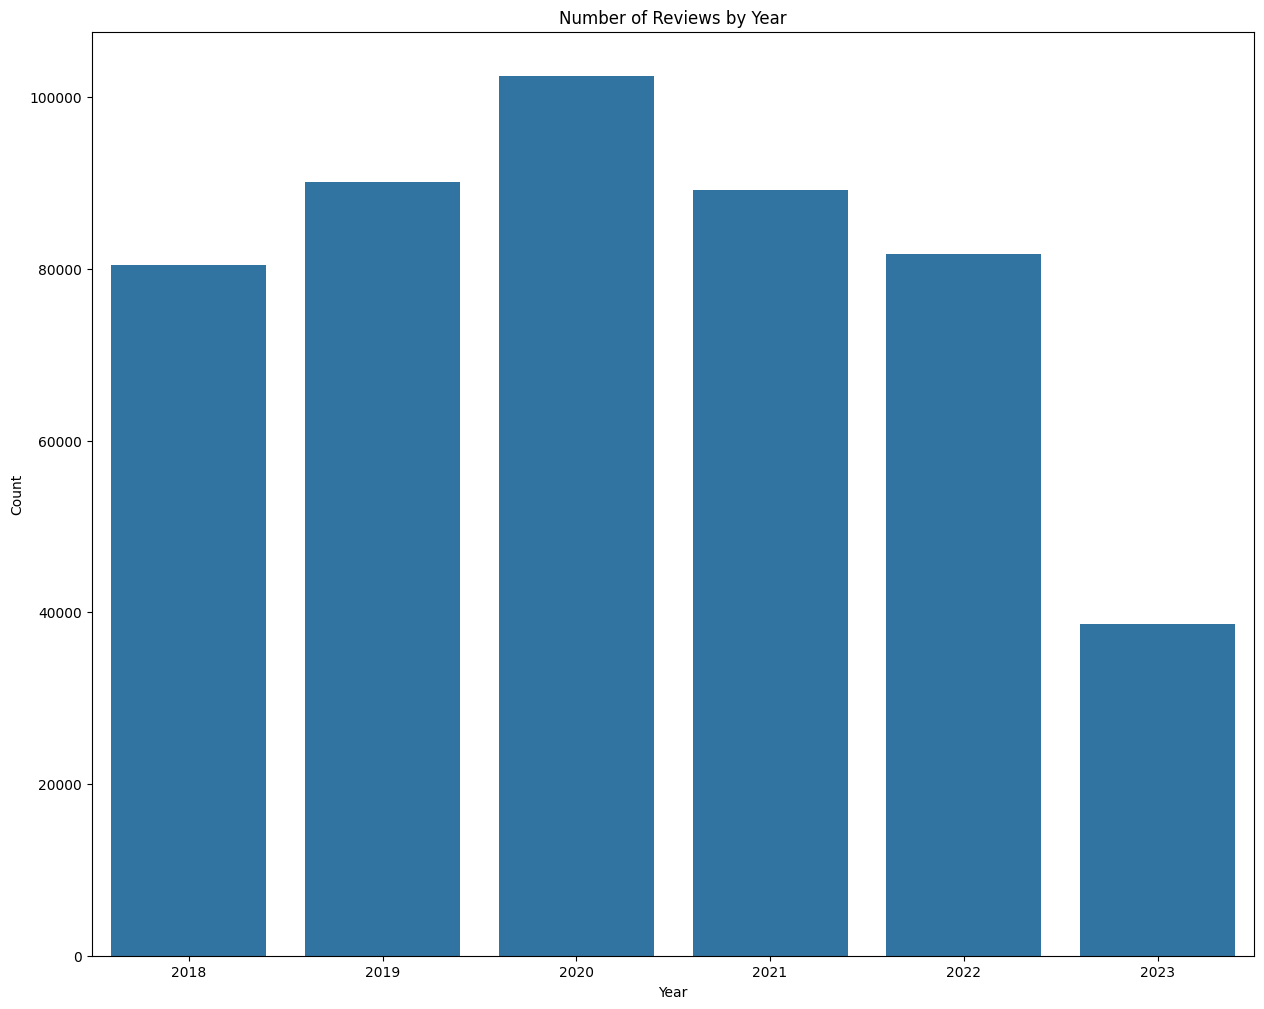

In [ ]:
plt.figure(figsize=(15,12))
reviews['year'] = reviews['date'].dt.year
sns.countplot(data=reviews, x='year')
plt.title("Number of Reviews by Year")
plt.xlabel("Year")
plt.ylabel("Count")

**Note**: Big shift started in 2020 (COVID)

In [ ]:
last_review = reviews[reviews['date']==reviews['date'].max()]
last_review

,parent_asin,rating,review_title,review_text,verified_purchase,helpful_vote,product_title,price,average_rating,rating_number,main_category,date,rating_delta,price_missing,year
234917,B07SRMJPFW,2.0,DOGGED LAPTOP,The Dell Laptop sent has seen better days. It ...,True,0,Premium Dell Latitude E6430 14 Inch HD Busines...,NaN,4.2,57,Computers,2023-09-09 23:11:31.845,-2.2,1,2023


**Note**: The distribution of reviews dropped in 2023 because the data only contains until 9/9/2023 -> more valid to compare by year from 2018-2022.

Text(0, 0.5, 'Count')

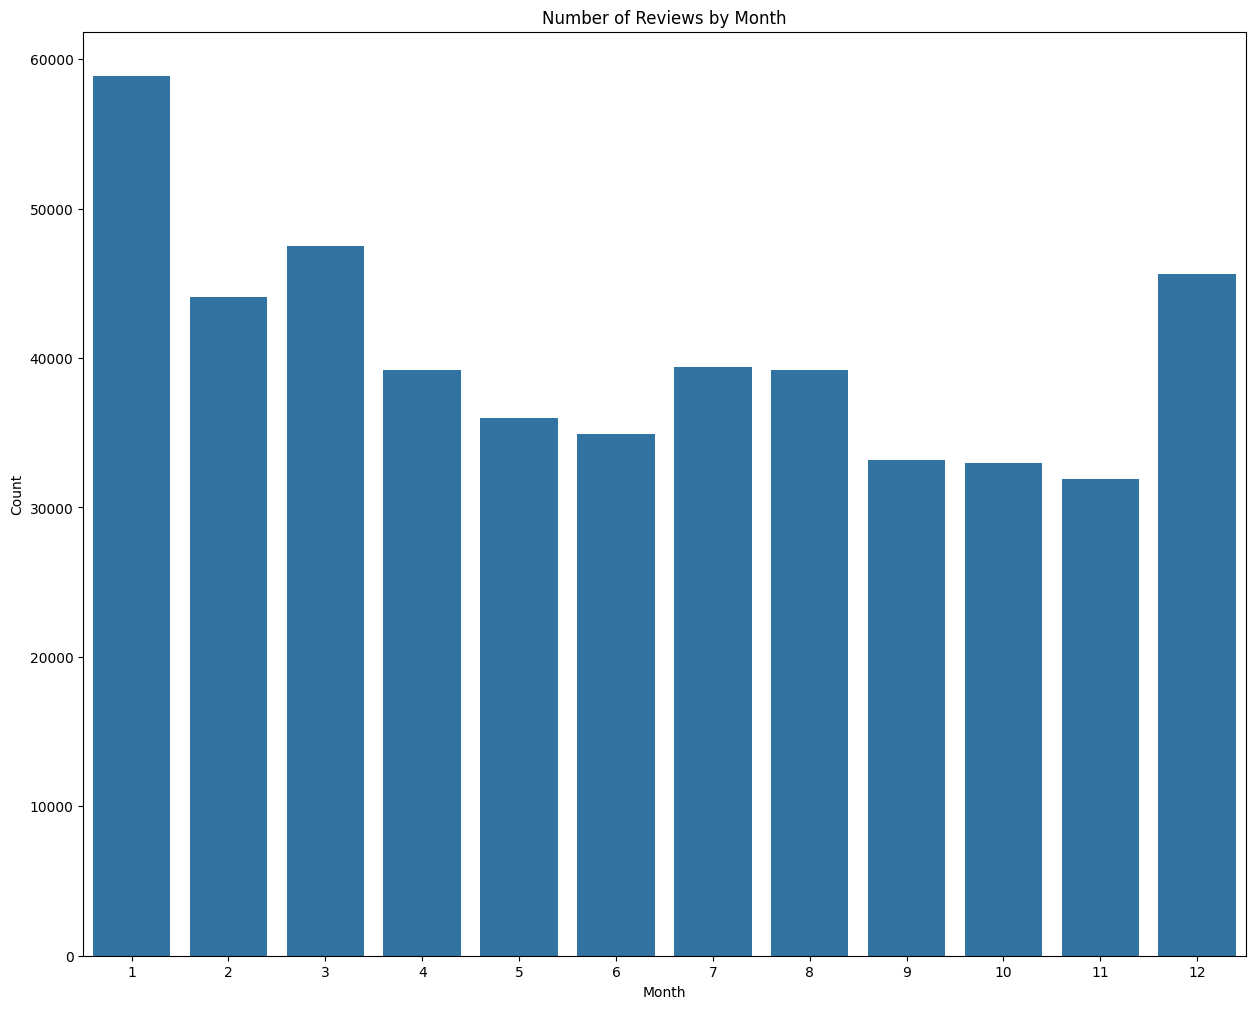

In [ ]:
reviews['month'] = reviews['date'].dt.month
plt.figure(figsize=(15,12))
sns.countplot(data=reviews, x='month')
plt.title("Number of Reviews by Month")
plt.xlabel("Month")
plt.ylabel("Count")

**Note**: Sep-Dec losing data. Dec and Jan performed extremely well.  

(6000.0, 17128.65)

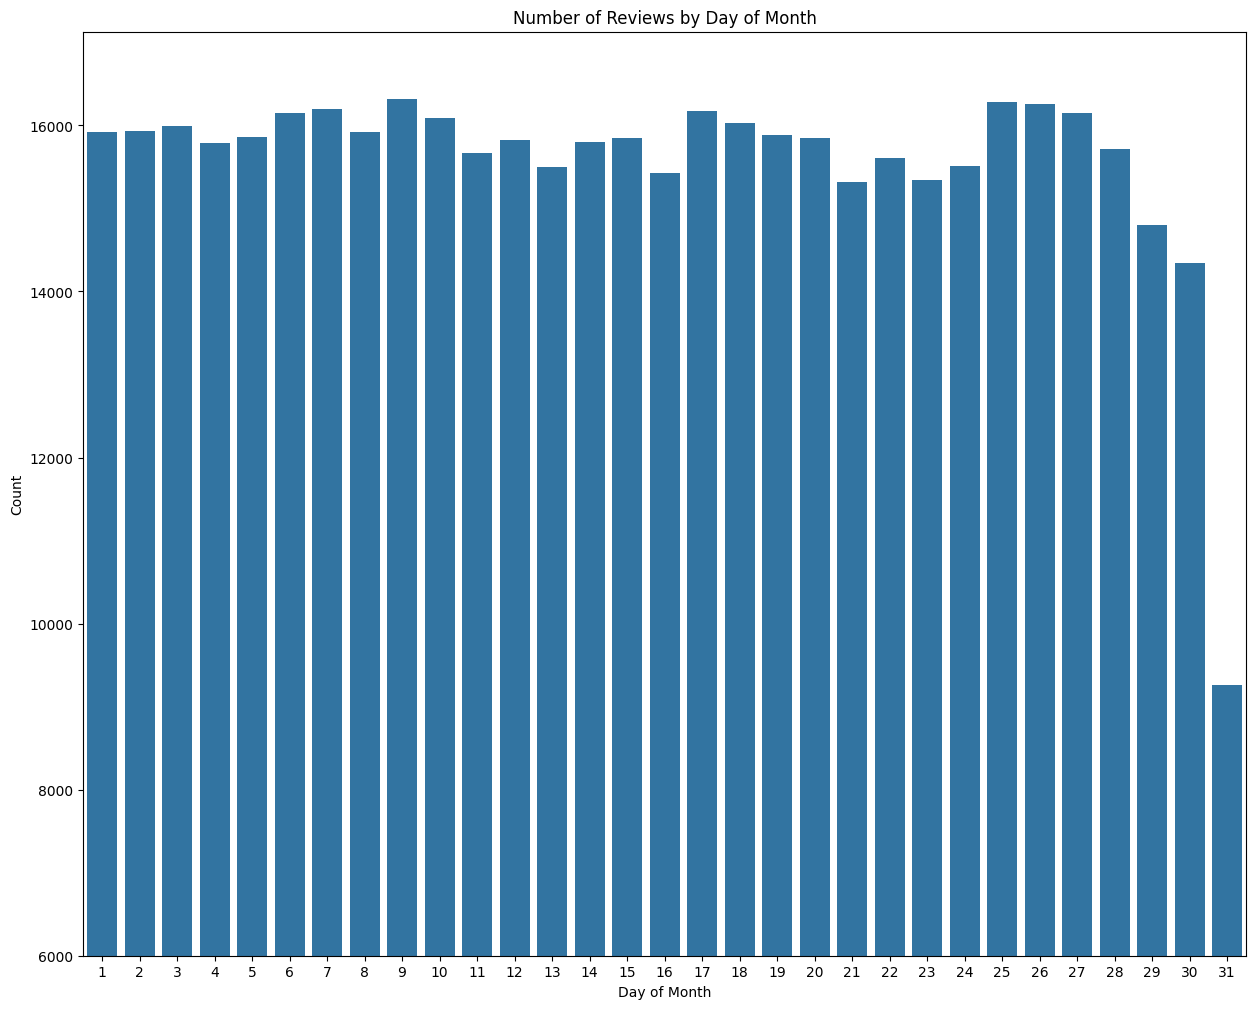

In [ ]:
reviews['date_of_month'] = reviews['date'].dt.day
plt.figure(figsize=(15,12))
sns.countplot(data=reviews, x='date_of_month')
plt.title("Number of Reviews by Day of Month")
plt.xlabel("Day of Month")
plt.ylabel("Count")
plt.ylim(6000,None)

**Note**: Nothing special about day of month. 31 low is understandable

(40000.0, 76112.4)

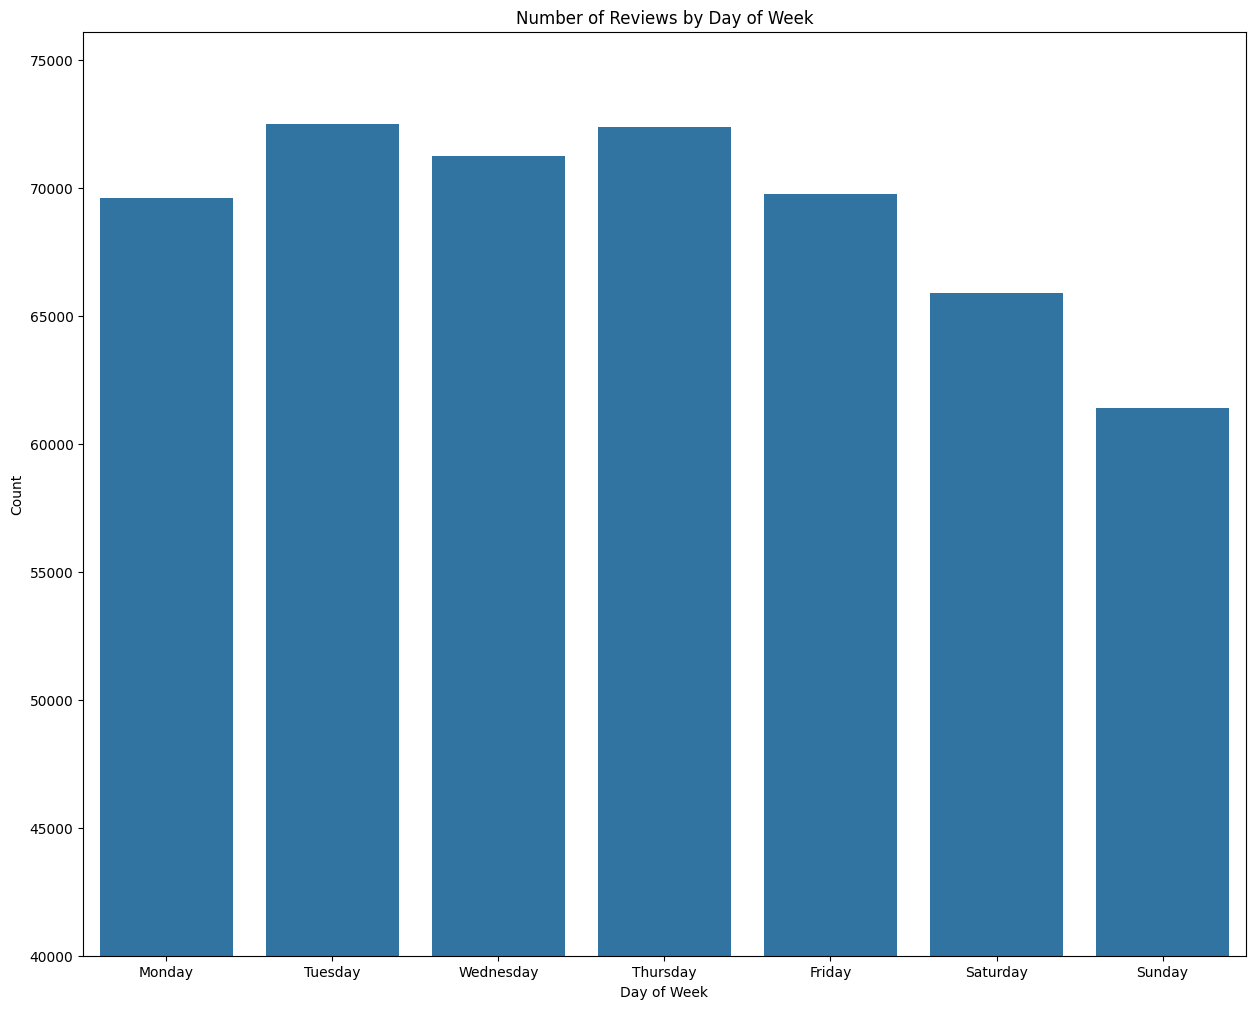

In [ ]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

reviews['day_of_week'] = reviews['date'].dt.day_name()
plt.figure(figsize=(15,12))
sns.countplot(data=reviews, x='day_of_week', order = order)
plt.title("Number of Reviews by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.ylim(40000,None)

**Note**: Less reviews on weekend

#### Spending by Year, Month (assume that product got review within a month/same year)

In [ ]:
with_price['year'] = with_price['date'].dt.year
with_price['month'] = with_price['date'].dt.month
spending_by_year_month = with_price.groupby(['year', 'month'])['price'].sum().reset_index()
spending_by_year_month

/tmp/ipython-input-154/3172845415.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  with_price['year'] = with_price['date'].dt.year
/tmp/ipython-input-154/3172845415.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  with_price['month'] = with_price['date'].dt.month


,year,month,price
0,2018,1,1164485.39
1,2018,2,1081226.28
2,2018,3,1224672.09
3,2018,4,1016796.38
4,2018,5,923210.26
...,...,...,...
64,2023,5,1319099.34
65,2023,6,860338.14
66,2023,7,612505.88
67,2023,8,464948.04


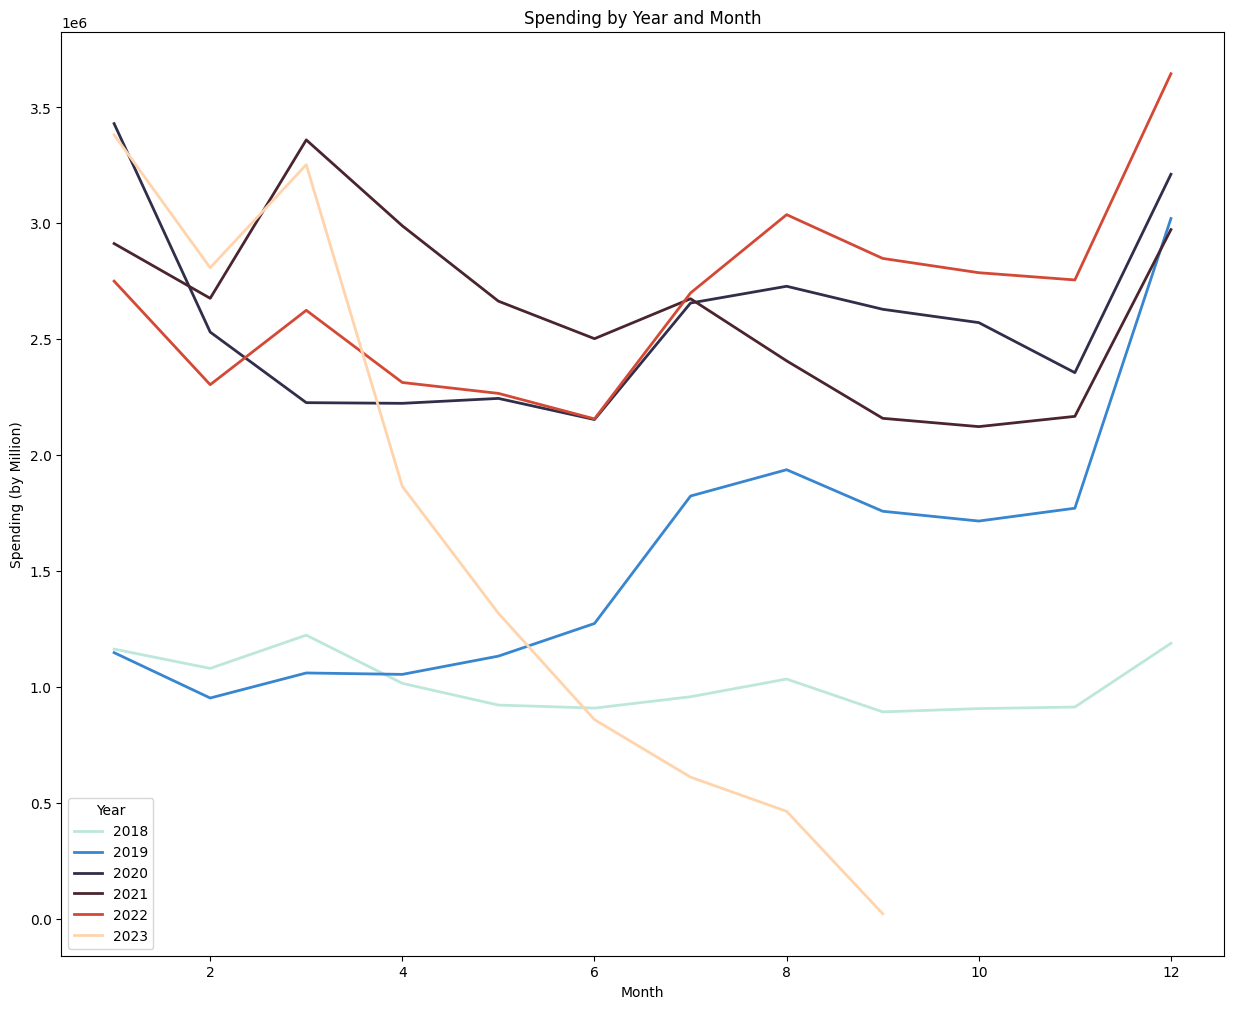

In [ ]:
plt.figure(figsize=(15,12))
sns.lineplot(
    data=spending_by_year_month,
    x='month',
    y='price',
    hue='year',
    palette='icefire',
    linewidth=2
)
plt.title("Spending by Year and Month")
plt.xlabel("Month")
plt.ylabel("Spending (by Million)")
plt.legend(title="Year")

**Note**: Every year, Dec has the highest spending.

### Texts

#### Length

Text(0, 0.5, 'Count')

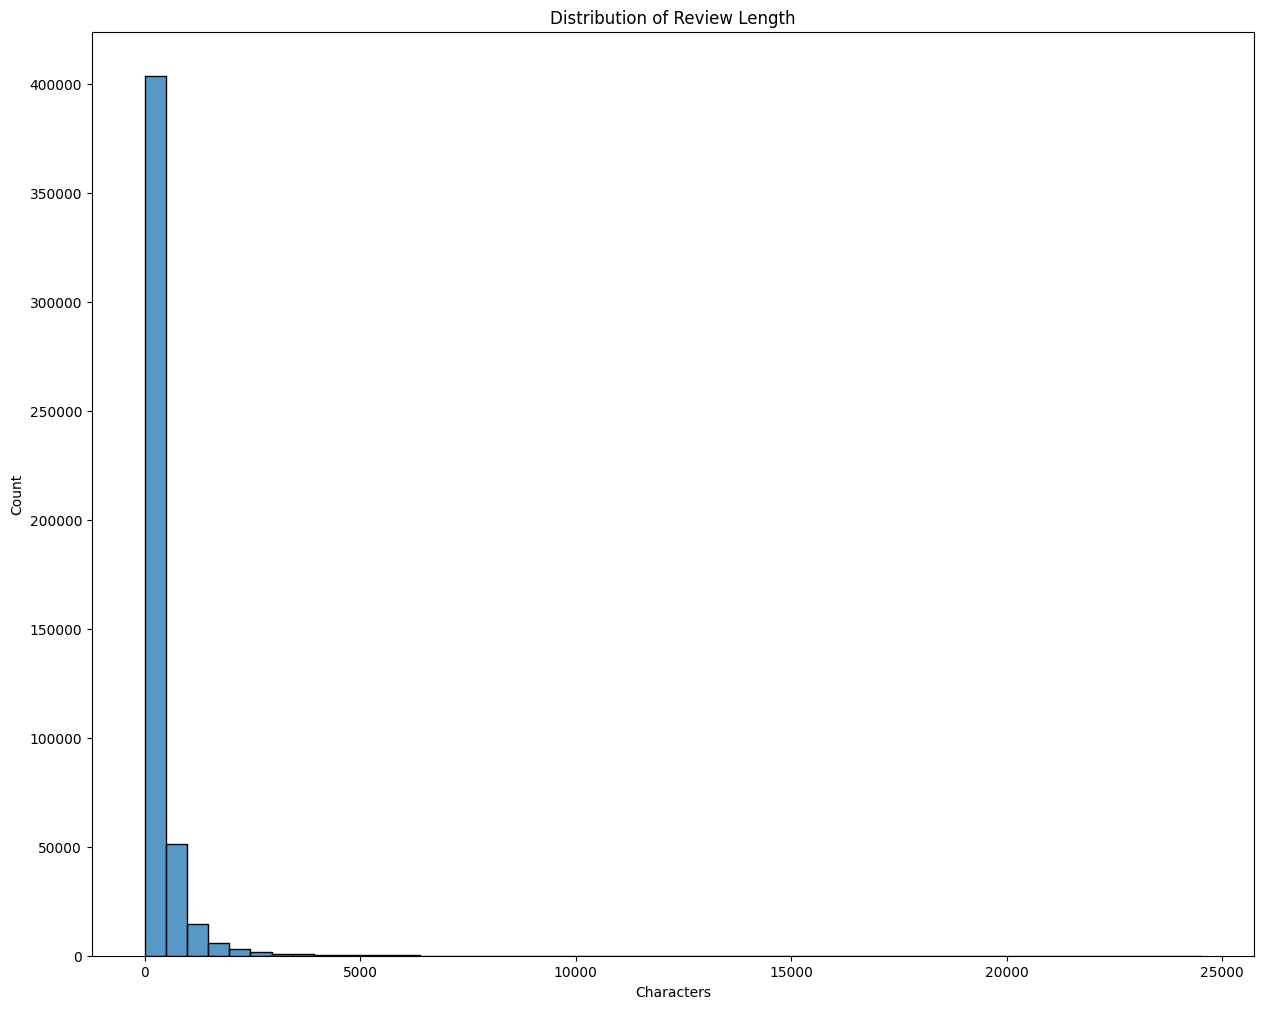

In [ ]:
reviews["review_length"] = reviews["review_text"].str.len()

plt.figure(figsize=(15,12))
sns.histplot(reviews["review_length"], bins=50)
plt.title("Distribution of Review Length")
plt.xlabel("Characters")
plt.ylabel("Count")



*   Most reviews are short (<300 characters)
*   The distribution is right-skewed
*   A small number of reviews are very long (>2000 characters)



Text(0, 0.5, 'Review Length')

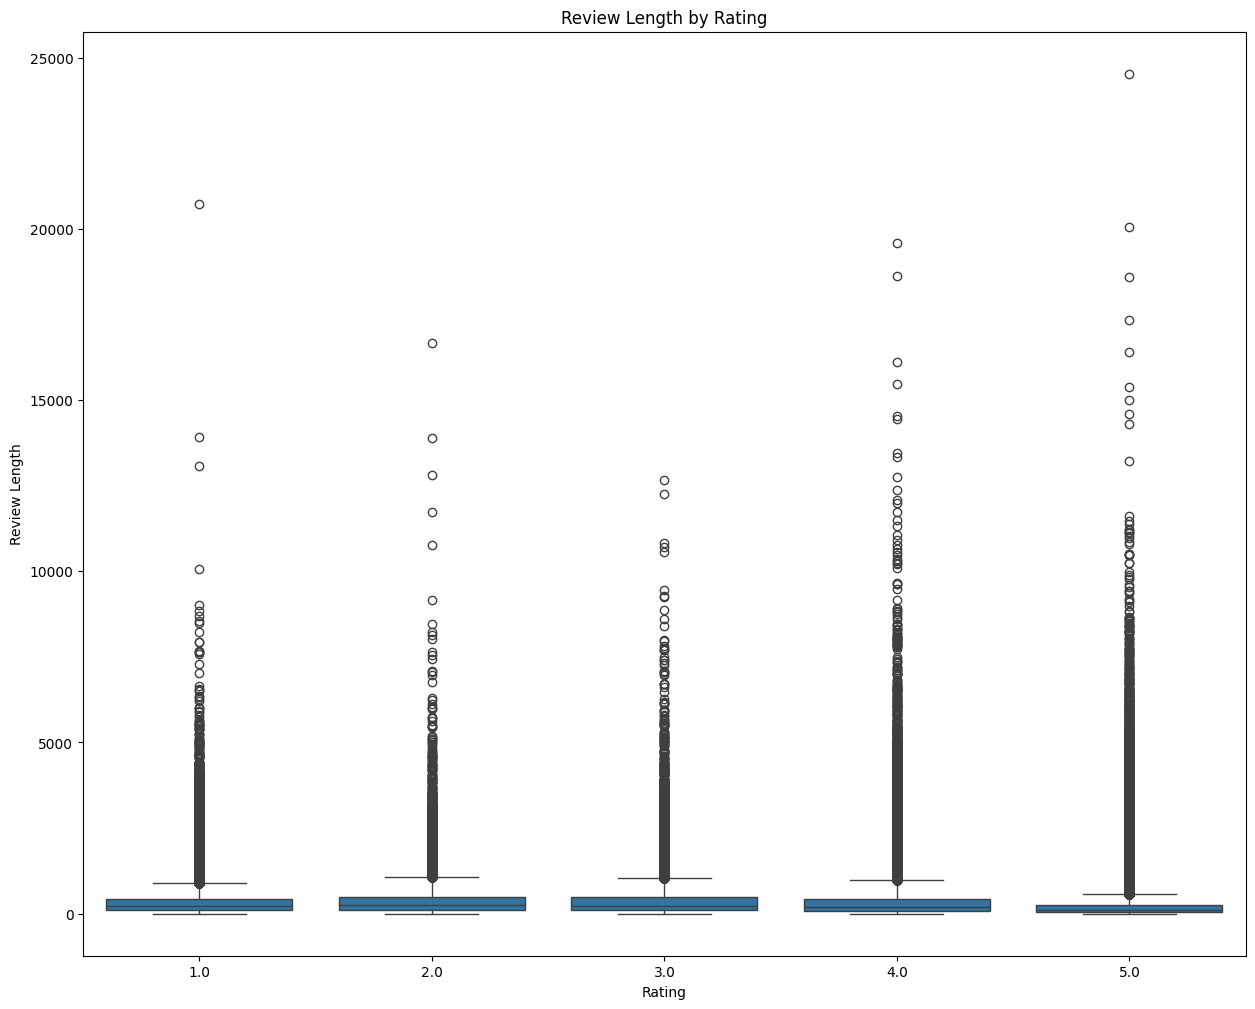

In [ ]:
plt.figure(figsize=(15,12))
sns.boxplot(
    data=reviews,
    x="rating",
    y="review_length"
)

plt.title("Review Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Review Length")



*   1-star reviews tend to be longer
*   5-star reviews are shorter on average



In [ ]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482776 entries, 0 to 482775
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   parent_asin        482776 non-null  object        
 1   rating             482776 non-null  float64       
 2   review_title       482776 non-null  object        
 3   review_text        482776 non-null  object        
 4   verified_purchase  482776 non-null  boolean       
 5   helpful_vote       482776 non-null  Int64         
 6   product_title      482776 non-null  object        
 7   price              297561 non-null  float64       
 8   average_rating     482776 non-null  float64       
 9   rating_number      482776 non-null  Int64         
 10  main_category      482776 non-null  object        
 11  date               482776 non-null  datetime64[ms]
 12  rating_delta       482776 non-null  float64       
 13  price_missing      482776 non-null  int64   

#### Reviews Text

In [ ]:
vader = SentimentIntensityAnalyzer()
def vader_sentiment(text):
    return vader.polarity_scores(text)['compound']

reviews['vader_sentiment'] = reviews['review_text'].apply(vader_sentiment)

In [ ]:
reviews

,parent_asin,rating,review_title,review_text,verified_purchase,helpful_vote,product_title,price,average_rating,rating_number,main_category,date,rating_delta,price_missing,year,month,date_of_month,day_of_week,review_length,vader_sentiment
0,B06XWPG52Q,1.0,No good,"There is nothing inside, just an empty shell. ...",True,6,*2017* Desktop Computer Intel Kaby Lake 3.6GHz...,NaN,1.0,6,Computers,2021-06-16 23:50:59.756,0.0,1,2021,6,16,Wednesday,80,-0.2023
1,B06XWPG52Q,1.0,"I received a computer case and not a ""Desktop ...",The title implied I would receive a desktop co...,True,3,*2017* Desktop Computer Intel Kaby Lake 3.6GHz...,NaN,1.0,6,Computers,2022-11-01 19:12:50.103,0.0,1,2022,11,1,Tuesday,329,0.2960
2,B09Q2Y7F9Y,1.0,JUNK!!!!!,"JUNK!!!! Do not waste your money, tablets won'...",True,0,"10 inch Android Tablet PC, 1280 * 800 IPS HD D...",NaN,1.0,3,Computers,2022-05-04 20:16:23.194,0.0,1,2022,5,4,Wednesday,103,0.5423
3,B09Q2W3FKV,1.0,The item is useless.,Android 9! No longer supported. EOL. Won't ...,True,0,"10 inch Android Tablet PC, 1280 * 800 IPS HD D...",NaN,1.0,1,Computers,2022-04-10 01:17:01.337,0.0,1,2022,4,10,Sunday,123,0.1906
4,B00MYR7HRQ,1.0,Received faulty product,Installed in my dell 11z laptop and it blew th...,True,0,"11.6"" Laptop LED Slim Screen Panels Display Fo...",35.75,1.0,2,Computers,2019-02-19 14:13:44.303,0.0,0,2019,2,19,Tuesday,86,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
482771,B0CGRM5FFZ,5.0,Newest 2020 Lenovo ThinkPad X280 Business Lapt...,Great laptop!,True,0,"lenovo ThinkPad L13 Yoga 2-in-1 Laptop 13.3"" F...",749.00,5.0,1,Computers,2020-12-29 20:17:58.875,0.0,0,2020,12,29,Tuesday,13,0.6588
482772,B0CGCVL9RS,5.0,Great computer,Computer shipped and arrived two days after pu...,True,0,"lenovo Yoga7i 2-in-1 Laptop | 16"" WUXGA IPS Mu...",729.00,5.0,6,Computers,2021-02-12 19:25:43.252,0.0,0,2021,2,12,Friday,168,0.4690
482773,B09YXGK2K1,5.0,So far so good....,I was looking for an upgrade over my existing ...,True,1,msecore Mini Desktop Computer with i5-9600KF 3...,1180.36,5.0,1,Computers,2021-10-27 16:09:17.338,0.0,0,2021,10,27,Wednesday,561,0.9381
482774,B0CDX5VTDM,5.0,Powerful microcomputer,The computer took a week to arrive and was wel...,True,0,"msecore Powerful Mini PC, Core i5-13400F 10 Co...",NaN,5.0,1,Computers,2021-03-21 12:38:54.491,0.0,1,2021,3,21,Sunday,1749,0.9420


Text(0, 0.5, 'Vader Sentiment')

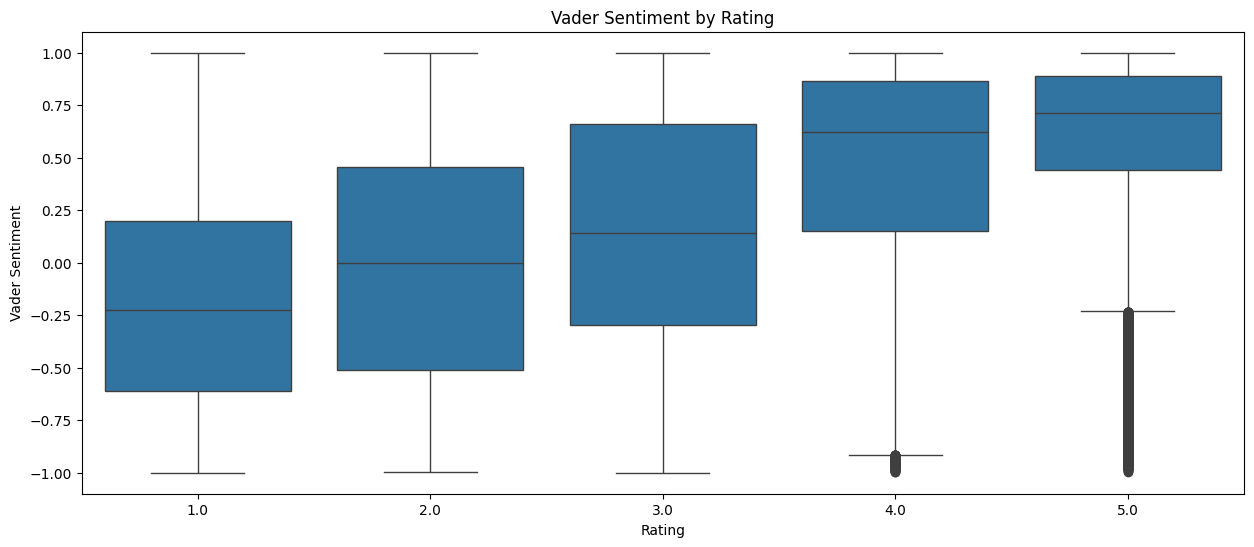

In [ ]:
plt.figure(figsize=(15,6))
sns.boxplot(data=reviews, x="rating", y="vader_sentiment")
plt.title("Vader Sentiment by Rating")
plt.xlabel("Rating")
plt.ylabel("Vader Sentiment")

**Note**: Overall, vader catches pattern correctly. Worth noticing that Vader might have mixed up with 4 and 5 star rating (because those answers might be a little too energetic -> model thinks it is negative). Or there might be chances that actually negative reviews but users gave good rating by mistake.

### Data Correlation

Text(0.5, 1.0, 'Correlation Matrix')

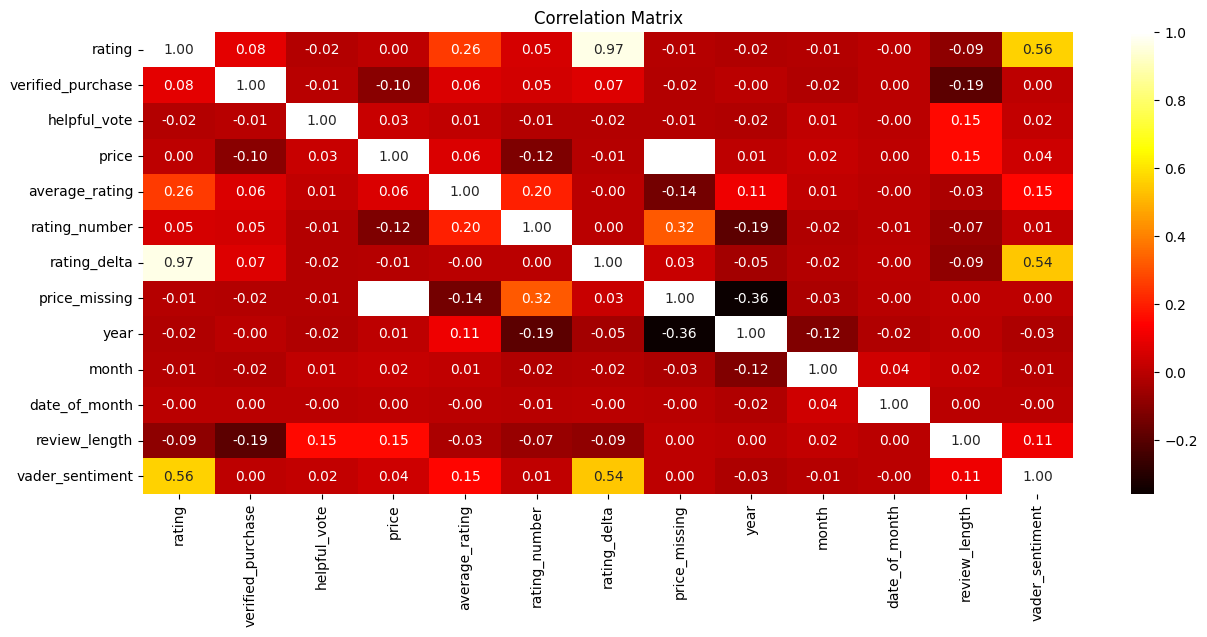

In [ ]:
plt.figure(figsize=(15,6))
correlation_matrix = reviews.corr(numeric_only=True)
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='hot',
    fmt=".2f"
)
plt.title("Correlation Matrix")

# Indepth Analysis and Data Handling

## Data Handling

### Text Handling


##### Title:

This step is used to both text handling and also categorize our data into 4 main categories: tablet, laptop, desktop, and other

In [ ]:
phone_re = re.compile(r"""
\b(

  # Apple
  iphone | iphone[\s\-]?\d{1,2}

  # Samsung Galaxy phones (S, A, Z series)
  | galaxy[\s\-]?s\d{1,2} | galaxy[\s\-]?a\d{1,2}
  | galaxy[\s\-]?z[\s\-]?(fold|flip)
  | galaxy[\s\-]?note

  # Google Pixel
  | pixel[\s\-]?\d{1,2}

  # OnePlus
  | oneplus[\s\-]?\d{1,2}

  # Other Android brands
  | moto[\s\-]?g | moto[\s\-]?e | moto[\s\-]?z
  | xperia | redmi | poco | realme
  | nokia[\s\-]?\d | lg[\s\-]?v\d | lg[\s\-]?g\d

  # Generic
  | smartphone | smartphones
  | cell[\s\-]?phone | cellphone
  | mobile[\s\-]?phone | phones | phone
)\b
""", re.IGNORECASE | re.VERBOSE)

tablet_re = re.compile(r"""
\b(

  # Apple
  ipad | ipad[\s\-]?(pro|air|mini)
  | ipad[\s\-]?(pro|air|mini)[\s\-]?\d{1,2}

  # Samsung Galaxy Tab
  | galaxy[\s\-]?tab | galaxy[\s\-]?tab[\s\-]?s\d
  | galaxy[\s\-]?tab[\s\-]?a\d

  # Amazon Fire
  | kindle[\s\-]?fire | fire[\s\-]?(hd|hdx)
  | fire[\s\-]?\d{1,2}

  # Microsoft Surface (tablet mode)
  | surface[\s\-]?go | surface[\s\-]?pro

  # Other
  | lenovo[\s\-]?tab | lenovo[\s\-]?yoga[\s\-]?tab
  | huawei[\s\-]?matepad | huawei[\s\-]?mediapad

  # Generic
  | \btablet\b | tablets | drawing[\s\-]?tablet

)\b
""", re.IGNORECASE | re.VERBOSE)


laptop_re = re.compile(r"""
\b(

  # Generic device types
  laptop | laptops | notebook | notebooks
  | desktop | desktops | workstation | workstations
  | all[\s\-]in[\s\-]one | mini[\s\-]?pc | nuc

  # Apple
  | macbook | macbook[\s\-]?(pro|air)
  | imac | mac[\s\-]?mini | mac[\s\-]?pro | mac[\s\-]?studio
  | mac[\s\-]?desktop

  # Dell
  | inspiron | latitude | xps[\s\-]?\d{2}
  | precision[\s\-]?\d{4} | vostro
  | optiplex | alienware

  # HP
  | pavilion | spectre | envy[\s\-]?\d{2}
  | elitebook | probook | zbook
  | omen[\s\-]?\d{2} | hp[\s\-]?elite[\s\-]?desk

  # Lenovo
  | thinkpad | thinkbook | ideapad
  | yoga[\s\-]?\d{3} | legion[\s\-]?\d{1}
  | ideacentre | thinkcentre | thinkstation

  # Asus
  | vivobook | zenbook | rog[\s\-]?(zephyrus|strix|flow)
  | asus[\s\-]?tuf | proart[\s\-]?studiobook

  # Acer
  | aspire[\s\-]?\d | swift[\s\-]?\d
  | predator[\s\-]?(helios|triton)
  | nitro[\s\-]?\d | spin[\s\-]?\d
  | chromebook | acer[\s\-]?veriton

  # Microsoft Surface
  | surface[\s\-]?laptop | surface[\s\-]?book
  | surface[\s\-]?studio

  # MSI
  | msi[\s\-]?(creator|stealth|raider|vector|cyborg|modern|prestige)

  # Razer
  | razer[\s\-]?blade

  # LG
  | lg[\s\-]?gram

  # Samsung (laptop)
  | galaxy[\s\-]?book

  # Framework
  | framework[\s\-]?laptop

)\b
""", re.IGNORECASE | re.VERBOSE)


desktop_re = re.compile(r"""
\b(
  # Generic form factor terms — unambiguous
  \bcomputer\b | \bpc\b| \bworkstation\b
  | \btower\b  | \bnuc\b    | \bsff\b
  | \bmicrotower\b | all[\s\-]in[\s\-]one
  | \bsmall[\s\-]form[\s\-]factor\b

  # PC combinations
  | mini[\s\-]?pc
  | gaming[\s\-]?pc
  | business[\s\-]?pc
  | desktop[\s\-]?pc   | pc[\s\-]?desktop
  | \bpc\s+tower\b     | tower[\s\-]?pc
  | \bpc\s+computer\b  | prebuilt[\s\-]?pc
  | \bpc\b(?=\s*[\(,])

  # Computer combinations
  | desktop[\s\-]?computer
  | tower[\s\-]?computer
  | gaming[\s\-]?computer
  | business[\s\-]?computer
  # Apple desktops
  | \bimac\b     | mac[\s\-]?mini
  | mac[\s\-]?pro | mac[\s\-]?studio

  # Dell desktops
  | \boptiplex\b
  | \bprecision[\s\-]?\d{4}\b
  | dell[\s\-]?vostro[\s\-]?\d{4}

  # HP desktops
  | \belitedesk\b  | \bprodesk\b
  | hp[\s\-]?compaq | \bcompaq\b
  | hp[\s\-]?slimline

  # Lenovo desktops
  | \bideacentre\b | \bthinkcentre\b | \bthinkstation\b

  # Asus desktops
  | \bexpertcenter\b | asus[\s\-]?vivo[\s\-]?pc

  # Acer desktops
  | acer[\s\-]?veriton | acer[\s\-]?aspire[\s\-]?tc

  # Gaming desktop brands
  | \bibuypower\b | \bskytech\b
  | \bperiphio\b  | \bavgpc\b | \balarco\b
)\b
""", re.IGNORECASE | re.VERBOSE)


def classify_device_type(title: str):
    if phone_re.search(title):
        return "phone"
    if tablet_re.search(title):
        return "tablet"
    if desktop_re.search(title):
        return "desktop"
    if laptop_re.search(title):
        return "laptop"
    return "other"

In [ ]:
test = reviews.copy()
test['category'] = test['product_title'].apply(classify_device_type)

In [ ]:
test['category'].value_counts()

,count
category,
laptop,207422
desktop,152576
tablet,111862
other,8740
phone,1674


**NOTE**: REPLACE THIS WITH MANUAL FILTERING 😭

**FILTER OTHER**

In [ ]:
real_other = [
    "B07HM9CX87", "B079MGHY92", "B00H713QY2", "B07HP9X5T7", "B0B3D5V422",
    "B088JWLKDN", "B00I8C5ENU", "B074Y8Q2Z8", "B003FWHHYC", "B07XWXX2CB",
    "B00HXT8JF4", "B002OL9V9Y", "B0043FOOVY", "B08DMMZMC3", "B004UR9P9Q",
    "B01N4KVSPA", "B009F1G7ES", "B097M8N79B", "B084CZ9HSP", "B08M93NC35",
    "B0BJ7NFLKD", "B01GWSJA4U", "B00006AMS4", "B00DJWLX9S", "B081Z98L9X",
    "B008HJZCEK", "B07HPB1N2J", "B09448P2M7", "B078KPRHQ7", "B07XYB92DJ",
    "B00T9TV250", "B00M4L4MQG", "B09WK25BTC", "B003EM0SIA", "B016L3V1Z2",
    "B00008NGIB", "B08W5J15WB", "B00WAHHMOS", "B00T9TV2AK", "B00NT7E0IY",
    "B019I9YUEU", "B00N2D5D04", "B09GL2JMB8", "B004575BIU", "B09LR9TLY3",
    "B075FFDB66", "B00M4L4RHU", "B07DDMD9KK", "B011P211YK", "B07F2SJVTK",
    "B00N4ORWIM", "B008MDZXB8", "B07WXMBFPL", "B01JGYUB6I", "B00M4LXD34",
    "B00VQQSOG4", "B019I9S4PQ", "B07235344W", "B008J4AZHM", "B014VUGIKA",
    "B079K21RN3", "B0013K2YMI", "B00JHAJNO8", "B00B4BK1OE", "B07JNLDJN3",
    "B08P2RVWSL", "B01BF12Z5A", "B07ZJYLPMK", "B017MWWQ7I", "B0848JWS4W",
    "B07957NMGW", "B08B5Z5JTZ", "B009F1DTZI", "B01435J4MC", "B01HGWC142",
    "B01NBEZR3Y", "B07D8ZN6RJ", "B017THLEBK", "B07FLFC5FB", "B019NCI944",
    "B00M0QPQYM", "B07HFJXGTF", "B016L3OC4E", "B00H7MCSAO", "B011JFX2C2",
    "B07JN7RBYR", "B00O9AGV1Y", "B072BYCRNF", "B076PB6HCS", "B0892LXZJJ",
    "B07QGWR8GB", "B084V9FCLL", "B07Z5BMQS4", "B011QIID3K", "B011QIJ5A0",
    "B017THRRKC", "B011QIIW54", "B014DT8366", "B07BLMS5TG", "B00LXT3MBG",
    "B0BDVQJHP2", "B07NY547C9", "B00L9VERQ2", "B08DG618MS", "B07WV2LJM4",
    "B003ZXCK8Y", "B083MJ96PL", "B09TS1GHP3", "B07BHPNZ7P", "B011QIIRQS",
    "B0012JNQYK", "B07QY482ZZ", "B07M79HPLX", "B07RYWZJDT", "B00I4QJV3O",
    "B08LZPSMYM", "B077TYWCNY", "B00008PBUS", "B00LG71M9Y", "B08TMV9FW5",
    "B003EM2WS4", "B014VY6JFA", "B0046T11TK", "B006UIS53K", "B07XLYBSQL",
    "B07J5QLMR4", "B088BVGW54", "B07Z5PNK5J", "B07TYPPV4S", "B08DDF64L8",
    "B011QIIEXO", "B00K5J22GG", "B09RGBBWNF", "B01JIQ6VUE", "B014VUE4PQ",
    "B000031WCP", "B01LXHI2MT", "B081ZCVZLM", "B08PDPML6S", "B08LQX2ZX6",
    "B08V23HH48", "B01L0E7DP4", "B011QII9DE", "B011SLD80S", "B08CRZV27M",
    "B07HFJLXZJ", "B09HKTQMSQ", "B00004Z9AJ", "B0030L3B8E", "B076PM8WQ6",
    "B008ACVF9A", "B093KBWDZP", "B07HBNCY8Z", "B008AZRMSK", "B00DU5AVDS",
    "B00AKIPTC6", "B09KW4FNNC", "B09P4FS4NG", "B07HCN5MRN", "B07GW2RYPW",
    "B084L2378N", "B088CYXK6W", "B07MXPMJHD", "B01B2YLQ6E", "B01B2YLPLA",
    "B01IC2VY7K", "B00FE2M9K8", "B07FW7F8WT", "B01KIUESVI", "B087N62D6X",
    "B01J8YFPOO", "B08DDCLS5P", "B01AY7V1SI", "B08FTKL6NH", "B00A8WR062",
    "B01B2YLS7G", "B01IC2W0IW", "B0047EJO1G", "B010T6DQTQ", "B07DM9235N",
    "B0793GNLJF", "B0918HR7VJ", "B081Z9L7DX", "B074PYK939", "B00ZL6M1XM",
    "B00317C02A", "B0BZN6P67X", "B016YJWPSK", "B07ZV2M2S4", "B002GBOFSO",
    "B01BK7F178", "B0BKNFLLL1", "B00O1A7XDM", "B08HVHQ3T7", "B07WSFGQ26",
    "B07141R9XN", "B06XDDW7X9", "B014VTVEWI", "B078T2XSS4", "B086MW75V8",
    "B005ONT3QA", "B001R84DGG", "B0093HNC10", "B07DWJ4WGR", "B009AD6BS8",
    "B07VWV3DW8", "B004EF8B76", "B07D6WG38P", "B08FLXHHWL", "B009ZKYI36",
    "B014ROMGYM", "B07PPXCL4C", "B01MTYALA3", "B014VUDYJ8", "B014ROIGXM",
    "B01EZPX3VS", "B079W648Y2", "B08L8J7XNR", "B07N2ZW7LW", "B07Q1CV82J",
    "B07XBR4YY5", "B0BNBSMLPP", "B013FJEH1U", "B018456588", "B01IDUJ798",
    "B087N85449", "B087YJ1NGC", "B013TYPUL2", "B004572VO2", "B01HOM98QI",
    "B08NH5WW4P", "B07L3F5D19", "B07XCM94SN", "B08GCSRS3P"
]

In [ ]:
test = test[~test['parent_asin'].isin(real_other)]

In [ ]:
other_laptop_parent_asin = [
    "B08113LD2J", "B07FW86HB2", "B07MSBPJTK", "B01GAJ166Q", "B07Q7XKJG7",
    "B07XKBJX4R", "B07Y2DMY39", "B01MEESR3Q", "B097B3WVB3", "B01KKJT5P6",
    "B07NRWZYH9", "B072PR8GR4", "B07HDVHPSF", "B019ZTV1WM", "B01INVTPE4",
    "B07J9PQXPB", "B071NLF1BZ", "B079K7YGV9", "B07Z7H92T4", "B075FB3TYD",
    "B077BC21GJ", "B06VYFRF61", "B06X97G1S4", "B075RHSHLJ", "B07RFKL7GN",
    "B08NFKD18V", "B07H823NZM", "B099LLSBQW", "B00HWM5PJU", "B09BZW4SW4",
    "B008C7C1E6", "B073GDS46R", "B01M3Y3TWO", "B009JXJXAC", "B07MHXX3G2",
    "B08YZ9TG8R", "B07DM3VN9Q", "B01ER4AQ9O", "B01N5VKVB1", "B07D4ZMYCM",
    "B07V421MVB", "B0754YMJ67", "B073WQNF36", "B07MXQNYKZ", "B00TL7LNKY",
    "B092W9VPL8", "B00EC4QJAU", "B08WYLS34W", "B079T8JW58", "B00FMCBK6O",
    "B01KSJU8Y0", "B007CKOG42", "B083ZLFFPB", "B082P5TQ92", "B0793BSQQD",
    "B07K1N9752", "B01N5RBNI1", "B00BFFEBE0", "B09MR213L7", "B08777VPVX",
    "B01G2C5KJ0", "B079RLB975", "B0083PR78C", "B00E6J2SN8", "B00EY50MVO",
    "B00JXLGEC0", "B06W9P66FS", "B00CW7MKSY", "B009TM70IU", "B081YBRXZR",
    "B08ZRC54VH", "B095BX4SLL", "B08WYKDJ3G", "B07RDJ8PC5", "B009E9KKGW",
    "B00R45UMSE", "B00BBMGZF0", "B01D7EMWYC", "B01KZWCVQ8", "B0BFP9NRNL",
    "B0923DLGV4", "B00K67RPRS", "B01L3EXAC6", "B0094K2848", "B071Y5SZYR",
    "B076J8ZP9H", "B01C7UGSJC", "B01ER4AJWI", "B01HAQMR6G", "B00HZ4F3Z6",
    "B00AH4A950", "B0CD8XBXLM", "B08YLVBDM3", "B071KZ73LC", "B081Y3GFHZ",
    "B009AEPXAY", "B01DM29I7S", "B01BYG0VDY", "B00MVKUVLU", "B07MFDG8W1",
    "B076V56RD8", "B07CKB6D19", "B08Z9V7KWS", "B0BW1PVSQ9", "B088P9CQ6R",
    "B0098O6K3U", "B07MQ71YC3", "B09L1N5146", "B01M2X4G2K", "B017D79SL4",
    "B077GYQX6K", "B01HAQHE3M", "B073WQKF44", "B01M0O5MV6", "B01M7VW4M9",
    "B09VRRK8D9", "B0071N53EM", "B01MS01H6J", "B06ZZHMKPR", "B06ZXS286Y",
    "B072LSWFQD", "B07BYBK1CV", "B01E7Q07DW", "B01ER4ARCU", "B01F1Z787G",
    "B01MTF911G", "B07CR5RYDB", "B078TJ2Z7R", "B0BZJH8R4Q", "B07982CRJQ",
    "B07588SY5W", "B07VBY428R", "B07H7VQ166", "B08121F2C7", "B07YG7MPWS",
    "B07MTM9HTF", "B07HGVFBL1", "B083LBN5DD", "B0795ZRMYC", "B07CP1R5DV",
    "B00N4LFEI0", "B07CKLV8ZD", "B08741VZGL", "B07DFRKYSP", "B01M5BBIJS",
    "B077QNVH93", "B00CL8FW4S", "B005J2E2US", "B005J2DNHG", "B009JXK1T4",
    "B00AVYPLPY", "B01HAQHI7Y", "B07DS88P27", "B087NYZ8R7", "B087SFJ1HL",
    "B07BN2LR7Y", "B07F1XB5FK", "B077NVN4CW", "B01HAQBIVG", "B01BVX8BM8",
    "B07GN5Z96F", "B095B9F9XV", "B0BXH752KY", "B0838MYCKT", "B096CP7G6B",
    "B083M9V8M5", "B083M9ZWB6", "B084QD1QB7", "B00AW4OCZI", "B07CBFZ2Q3",
    "B07NL341NY", "B01I0560MS", "B0041RSE5Q", "B019FV6G34", "B083SS8MMZ",
    "B08SVF8GGN", "B08SVKJ6R6", "B08YMV3WT5", "B00N9CWWJS", "B08TBQYTDY",
    "B081565ZMY", "B072BGTQSY", "B07VYTJZFC", "B097WPNSGY", "B077J58D17",
    "B07G5QRMK4", "B01CU4E0KY", "B08Z2YCTC5", "B0C4CF7Y5X", "B082WHQJN7",
    "B071HYYB4M", "B07Y8W8F5Q", "B00Y9F4YUE", "B07PHM3934", "B076DHSSJF",
    "B01IG6NDNK", "B071CZMHZQ", "B077H2JY74", "B01B9HBP4C", "B01LD4ML30",
    "B00NC088EA", "B0141R3OV4", "B084QHRJLZ", "B072L7711F", "B079K1HBL5",
    "B073WQMKV4", "B07F2N9B59", "B09JL263CG", "B073WQHXR8", "B07PP1ZMQY",
    "B09C386RGG", "B00QE9UCZO", "B08HST79G4", "B00S1T2QBS", "B00CRJQG4G",
    "B07G66MSRH", "B0861G3BW1", "B01N2HO0VA", "B07W99R3F3", "B01K0OY2RM",
    "B08BZ3ZPG1", "B07BJXJ2R5", "B01C7UGPGS", "B077DN16ZX", "B01J42JPL4",
    "B019MJ3L78", "B004GCIYY2", "B004UR1670", "B008D9HZ62", "B01B24A3W2",
    "B01F1Z78RG", "B01F1Z78U8", "B06XSXFRV4", "B06XJFTYBL", "B07C4WKZMQ",
    "B07H82DZKS", "B075JSK7TR", "B07BFW9D9T", "B07SPFKBGV", "B07G36XGPM",
    "B07W5KSP3L", "B07F87JCMV", "B0BFCNKPCB", "B08BZ3XC8F", "B08BZ42SN1",
    "B09KQ3ZG2F", "B01M1BW7KK", "B07BFQWP7R", "B08288LGFQ", "B07D195XBL",
    "B07JVDVXJH", "B07HPYK24B", "B01MPXAPX0", "B074T13QP1", "B07RDJ8CGR",
    "B0C5HGQJBY", "B07LCGBGPF", "B0842V96QN", "B07SMX4QG2", "B009DXVVB2",
    "B00B4DIGXA", "B0B164K6GG", "B084L8Z4FP", "B084LJNVMC", "B07SC8X4GW",
    "B07RDJ8DRQ", "B01DO8F82Y", "B08121F9W2", "B08121HG8S", "B072STZXZ8",
    "B07JZ8DYPR", "B073ZND1FZ", "B07793T8LK", "B01LD4MGR6", "B06XDCRS12",
    "B00AAIC5S2", "B006ITMC7Q", "B006O7FLH0", "B014YN6YZ8", "B01N9C2C97",
    "B076CS5G1F", "B07F2KPLHD", "B0B3TSXVNF", "B07BZYQ4J2", "B01HAQG37A",
    "B07BX68HZY", "B087NXHDF8", "B08ZL6S7DS", "B07J5YBPZM", "B07DZJK8TK",
    "B079NNLCMG", "B075JLPLBL", "B07CMVB9J3", "B088JPPCFY", "B00TOW7T86",
    "B07RC92XDF", "B0B15NZRQT", "B09TL9DGK6", "B001R4L0Y8", "B098854S8C",
    "B07FP1QJ5P", "B071L1BPK8", "B077RCCYT8", "B07XKVHPRP", "B07ST48R6M",
    "B092BYWMNP", "B08CG9PZLR", "B09MHBY5HX", "B07HNJ2XKJ", "B008HBHHTG",
    "B0BWSD1XTX", "B0711WXD7Y", "B07SMND9DJ", "B08468B4FP", "B074MJRR36",
    "B079TGL2BZ", "B084TS138V", "B01N4FLSD0", "B004UR16ES", "B078NPYG9Y",
    "B077P34GJ2", "B081XL7H37", "B07MF4GQW6", "B07RXWPNG4", "B07NMSYLF4",
    "B0778HR29P", "B074HDXBC7", "B07PVCLSDZ", "B07DN3JNP6", "B07F35XY9N",
    "B07VTB2BF2", "B07HPWGP1X", "B08681C929", "B094W6QJY4", "B08MWQF4KG",
    "B07G2RG7JH", "B012B6YQF0", "B0956JKSH7", "B095C23PMJ", "B087QXGHSG",
    "B08KFP1Y1P", "B07SPQ37DS", "B083NR5R2G", "B082WMS2DT", "B08B17W9B6",
    "B07Y7P9P96", "B01M6CRZP4", "B08V5B4425", "B07H471WQT", "B001FWXFKE",
    "B01M5G7EQ3", "B0CFT86RRQ", "B09V8GB2CK", "B08J8GPPH2", "B08HXCGW87",
    "B09BMGCVZH", "B081Z793P8", "B09PFYW194", "B07GDDSJNH", "B0B6GJDM6W",
    "B07DN22J16", "B0C72SSP6X", "B09Y78B5GY", "B09QPP787G", "B00QX89YQ4",
    "B08HVB86ZK", "B01N1RM6N5", "B07XZP24L3", "B07MBSJYF9", "B07XQLJ7K3",
    "B07Y8QRX7W", "B0956JJVXG", "B07Z8GZH4P", "B08NWD6S2V", "B084MNHG2S",
    "B084P7T4NY", "B084QJRXFW", "B07HRJZY9D", "B07RKL5QL5", "B082PMG1GQ",
    "B071YPCBTS", "B075FLJ87G", "B0BHNFKVMV", "B0C6KL9LKQ", "B07G8Z3QQT",
    "B09W59DNH5", "B09JJ5MJX3", "B07QNM6LGW", "B09V6NMDGZ", "B07F21W1GX",
    "B09LJPW1SQ", "B01M7VVCSK", "B0C5S191L7", "B0C9QXRX79", "B087D8TH7W",
    "B07N75WXT2", "B09TDSWLCM", "B07XGNN51H", "B07SHNQ8FV", "B084RNT2JB",
    "B08HZ8WY6R", "B0B5KR26ZL", "B08TCXDZWS", "B09NJWJL85", "B0886GXT6L",
    "B07797QV9M", "B08JHHK1G1", "B08SVGYD5D", "B08SW98K2G", "B08SVF5RFG",
    "B07S5MNMT2", "B07BBDLRMB", "B081D7C6CD", "B08558L133", "B08121T49K",
    "B005E18T94", "B08V9DVJGK", "B089S9N86P", "B08HMWYRK6", "B07YXSLFDH",
    "B0867HF7XR", "B07RFKK878", "B07VVMF51P", "B089RWZZ1G", "B07F73YGZJ",
    "B081217DYJ", "B0811ZZMP9", "B08L8W2WJ8", "B092CMW6K9", "B083NQ3KP8",
    "B083JNK965", "B086L5P6D1", "B08XWDZ22S", "B071HZRD36", "B07SGZG3ZV",
    "B08NTCH21H", "B09KQY4RWR", "B07BJYD4QT", "B09DB2MG5M", "B084GQ1HG4",
    "B08ZBZ651Q", "B09XWMPBM5", "B088FY251L", "B07YNTR349", "B002QK22YO",
    "B08CBLWPQS", "B09QK7MT7T", "B07PDHTGQ2", "B0C3G9GZH1", "B0CFKFW9MM",
    "B0BW8PGDSV", "B083ZMDKZG", "B08R6L1Z2L", "B08K99DGJF", "B083MVFXP8",
    "B081FJNWD4", "B07Y25H9Z3", "B07XB3B53Q", "B081226VGQ", "B07RDJ8HLC",
    "B0787HV7WM", "B071XTV7JC", "B087D7XTNT", "B099MBMQYL", "B07QC8L7K4",
    "B088FHF29H", "B07DN3FPKK", "B098TS26YZ", "B08WTQGJ55", "B0CGRDQ17V",
    "B07BK2XLHV", "B083M9BWXM", "B085F2VJCK", "B0787HK4MW", "B08ZKY469Y",
    "B09HLBM2CL", "B07QRZJRK9", "B08BK3SDT9", "B08L9WM9SF", "B08H8F1954",
    "B07HGQ7R1M", "B096T8KH67", "B08TCYDJ79", "B09B4KYWBG", "B08K3MY5K5",
    "B08K3LW7ZT", "B08SHL527P", "B07HZS73R1", "B087DV319X", "B0C1KQQXD6",
    "B08FGJ67ZL", "B08FGJB9X4", "B096L3KTLQ", "B007C5VOP6", "B07892Z7YL",
    "B071P6QWMH", "B072LMGSRW", "B01N59TYCO", "B086Z2L8M8", "B09F6MLXSZ",
    "B018VOO1LU", "B01B7QHJMW", "B008PB7VPI", "B07HFJX4G2", "B08VD39G88",
    "B07TMRF1GD", "B06XTVHWYQ", "B06X6GFQHG", "B07JKHN5WP", "B0CCSDV35W",
    "B08WCKF6WN", "B096QWS9T9", "B00CE5DIFS", "B09T3WHJDL", "B095DQ5WCJ",
    "B0993X4HP2", "B07JHFWMBH", "B01COKKSVY", "B08CCJ5QF5", "B081212H4B",
    "B093BJ7Z4R", "B076JRHXJG", "B0816ZWM5X", "B07VJG269Z", "B08N5RQBG8",
    "B09RQPX26Z", "B09TGXCPZC", "B079Y8R8PV", "B06XHKRZYX", "B09YGSVMVK",
    "B07LFDTSP5", "B09576KJTB", "B08ZSH1MYX", "B07C347PSD", "B0C3XW248Z",
    "B07R81HFCY", "B07VBH9TWS", "B07SWR3NVJ", "B07BT44PHY"
]

In [ ]:
mask_laptop = test['parent_asin'].isin(other_laptop_parent_asin)
test.loc[mask_laptop, 'category'] = 'laptop'

In [ ]:
other_tablet_parent_asin = [
    "B07MZCJG4B", "B072NXBWVH", "B073W1P6MC", "B074JH8N5P", "B07JMJ1D54",
    "B06Y6KTD8G", "B076H9ZGFH", "B01L9NO7D2", "B01G6HDQTM", "B073X22PVP",
    "B01B3Z8WJG", "B06XNX91YB", "B00VQLJ4D6", "B073WXR1QB", "B07GVQK742",
    "B0849RN16P", "B07CY2SG9J", "B005890G84", "B06XB1TGYW", "B07G8FVW5W",
    "B01F7WBUQ8", "B09NQJG4CJ", "B08JB39D5N", "B07ZQR2Z69", "B07WJW3JX4",
    "B0753CL6CY", "B01ER4AX9M", "B01F1Z7DEE", "B01F5LWSS0", "B0721BQD9M",
    "140053271X", "B07XLNH4LM", "B07X7X5VTM", "B084WXRYMN", "B0BK31GHQW",
    "B07RD1R31Y", "B08428CB3R", "B017A6S0FS", "B00KDRQEYQ", "B005890FN0",
    "B089GVTVBD", "B08318VQBG", "B0872FTSYD", "B08SJ6YLYF", "B06ZZ6Z1YZ",
    "B07V5NB2VK", "B01NAI7MGR"
]

In [ ]:
mask_tablet = test['parent_asin'].isin(other_tablet_parent_asin)
test.loc[mask_tablet, 'category'] = 'tablet'

In [ ]:
other_desktop_parent_asin = [
    'B07G38ZV1F', 'B01MXXGIP9', 'B079K7NG2Q', 'B01LYNC7LW', 'B07Y13NSGS',
    'B08122HNCP', 'B07WHJV4BK', 'B0795X7QMW', 'B07FB4MVPJ', 'B085W8YCMM',
    'B06XWVJVRL', 'B08L5FM8CD', 'B01JSGAJ8O', 'B013VTOQJC', 'B07YG6BJFS',
    'B073WQKFGB', 'B07RC97BHK', 'B016N644TW', 'B01IAJPQV0', 'B07G8Q7YN6',
    'B00K6UMEQM', 'B07659V53B', 'B084GC2HRK', 'B00YNSGDVA', 'B01IC5W9XU',
    'B07RKQT6WH', 'B076V1N1PM', 'B07WHHK346', 'B09CFY2CLW', 'B06XTDXLHQ',
    'B01N29DMKA', 'B081P34Y8N', 'B071FFW2RS', 'B07DF25M1W', 'B08MQRZMK5',
    'B09B4D9TBY', 'B07PW3XSHS', 'B07NKCTX7Y', 'B071XNG1BZ', 'B071G6QR4C',
    'B01FX8T8MO', 'B01G5JYQW2', 'B01HFJ476G', 'B074C73YCQ', 'B07MSD2PWT',
    'B013VTRR6Q', 'B01M33549X', 'B07X5CKYHD', 'B00EOEQ48U', 'B092P9PPGV',
    'B0722JRVCH', 'B08NTSH25Y', 'B07PJ21ZSQ', 'B00VSDJBEY', 'B01M7XVSTA',
    'B013PXTWSE', 'B01INVSFWC', 'B01G5JYD2U', 'B07GXY6JHV', 'B01J66AWD8',
    'B09LRLYBPS', 'B071G6QHDN', 'B01EUC7LWI', 'B082VG6XNZ', 'B01E690JCY',
    'B07FLP554Y', 'B097S84PPM', 'B07RKLF748', 'B017HD69Z2', 'B074VLX5YY',
    'B07SQ4VKTF', 'B073PGM8TY', 'B07SVG4ZZB', 'B016VEOXJW', 'B01MUUIXP2',
    'B07G8M4KKS', 'B08RSSN33Q', 'B07BRLMQZ8', 'B01ES0MUUA', 'B071P6ZJWT',
    'B07VC9MG95', 'B01MXIOHMY', 'B00KNM46QO', 'B09851VL4D', 'B08H8TCTT1',
    'B075F7L77R', 'B08D2YP45J', 'B06XY3FJC5', 'B0767S8KCX', 'B01I47TLK0',
    'B01JZPNRM8', 'B00VENDJN2', 'B07X276L57', 'B07TXHL1QF', 'B07FLCPPPK',
    'B07RQ9QS6B', 'B07RT1RCN6', 'B076VFQLZD', 'B076VF77XR', 'B01FX8T0TA',
    'B01FX8T8QU', 'B01MRLCGBK', 'B01DB04TF2', 'B07G8QQQ1R', 'B01MDOJIM1',
    'B071CW3DRV', 'B08V5641XG', 'B07DQS7HKC', 'B0BMT5YGJ9', 'B004M3UXLC',
    'B07CX639KW', 'B081217DYM', 'B014644FVA', 'B09N9F7HRK', 'B073GCMQDV',
    'B07CX8GKLZ', 'B07CXWYV5M', 'B017S118BI', 'B07JYLCBVP', 'B08G45VK6L',
    'B08ZRD1DRK', 'B07G9KYZDB', 'B07CZ1SMJP', 'B00OGMGECQ', 'B074N5YTB9',
    'B07HCTBSG1', 'B07W8GXBV2', 'B07VSBWF9M', 'B074V3L6LD', 'B0BDTSG2K1',
    'B08BLTB1C5', 'B09SP7V9X1', 'B07QB4Q2YR', 'B0BV3Y41MG', 'B084D1LCZL',
    'B08KZC88LY', 'B013KVAH62', 'B01MYEZ6HB', 'B00718XYIE', 'B087F2J3D4',
    'B08XLMCYT3', 'B08TJ5BLFY', 'B07MZ9W9BG', 'B0793D6LRT', 'B01HGWC8UE',
    'B074G2SPW9', 'B06ZZXCB32', 'B071W92JR3', 'B01MQJ9GSH', 'B079J25BCJ',
    'B076V8T1XQ', 'B01G5JYCC6', 'B07G9NKBN9', 'B07WJLW67S', 'B07SJ98XT6',
    'B07NJ9Q5TC', 'B075Y12HG2', 'B01MYQ6Q51', 'B09SNZY78Z', 'B09P4FBC7B',
    'B07JGQYQZ4', 'B07FB1BYZZ', 'B08Z6ZYZ6B', 'B09DTHRXP5', 'B07PXD5CHV',
    'B01N7D45PX', 'B07P2DGR85', 'B079J39CWS', 'B01BCDK1KC', 'B086RFBXDT',
    'B07R92BC49', 'B07DWDNCLV', 'B071J1KHVS', 'B00P8HTPOC', 'B01LB92MWM',
]

In [ ]:
mask_desktop = test['parent_asin'].isin(other_desktop_parent_asin)
test.loc[mask_desktop, 'category'] = 'desktop'

In [ ]:
test = test[test['category'] != 'other']

**FILTER PHONE**

In [ ]:
phone_tablet_parent_asin = [
    'B09XDYBRVR', 'B08XXW7QNQ', 'B0943LNS9D', 'B08R8N3ZRH', 'B09FLKL5SL',
    'B014LVI6HW', 'B08R9NCBNJ', 'B09N3J4X7Z', 'B07DZGPF7L', 'B07Z9FB8PF',
    'B09MQJHZ1S', 'B08R8QT7PY', 'B08R9H5H7Y', 'B092474HKB', 'B0923QPDG5',
    'B0713X2SPR', 'B08MZBSPW7', 'B08GKFL2TM', 'B09JK4VQ7X', 'B08XXPDN6J',
    'B08F2KGJXW', 'B08BKFWTPH', 'B08HCWSLNC', 'B086PVGJ41', 'B07563YPTN',
    'B08NPGQMS7', 'B08R8MTFYD', 'B07SBMG44N', 'B09STXFT8X', 'B09MKV8JRT',
    'B0BNYCFTYQ', 'B09N3KVZHQ', 'B09MQKRZPV', 'B0874B14QB', 'B08VNP52XG',
    'B09QW6MJTR', 'B07VD472G1', 'B087WRLT2R', 'B09PTQ1JVW', 'B0B3MPLCVF',
    'B08QJDNQ91', 'B0CB64GXRF', 'B00YR1JHK2', 'B086YBZJ9D', 'B086XBZ7NC',
    'B09L1C3231', 'B08VDP9MBK', 'B089K7JQ2M', 'B07NR9L3Y6', 'B094Z8J3Y9',
    'B094CZPLR3', 'B087P2R369', 'B0874HFPWR', 'B09VH1STX5', 'B09922CSKP',
    'B09L5ZZJ17', 'B0815T9G1K', 'B09NJM6HGN', 'B09ZKKQ137', 'B09KKMLR4R',
]

In [ ]:
mask_phone_tablet = test['parent_asin'].isin(phone_tablet_parent_asin)
test.loc[mask_phone_tablet, 'category'] = 'tablet'

In [ ]:
phone_laptop_parent_asin = ['B08QMB94YW']
mask_laptop_tablet = test['parent_asin'].isin(phone_laptop_parent_asin)
test.loc[mask_laptop_tablet, 'category'] = 'laptop'

Drop 3 phones and we are done with categorization

In [ ]:
test = test[test['category'] != 'phone']

In [ ]:
test['category'].value_counts()

,count
category,
laptop,215360
desktop,153547
tablet,112129


##### Brand Seperation

In [ ]:
brand_re = re.compile(r"""
(
  # Apple
  \bapple\b | \biphone\b | \bipad\b | \bmacbook\b | \bimac\b
  | \bmac[\s\-]?(mini|pro|studio|air)\b
  | \bairpods?\b | \bairtag\b

  # Samsung
  | \bsamsung\b | \bgalaxy\b

  # Dell
  | \bdell\b | \balienware\b | \bxps\b

  # HP
  | \bhp\b | \bhewlett[\s\-]?packard\b
  | \bomen\b | \bspectre\b | \bpavilion\b | \benvy\b
  | \belitebook\b | \bprobook\b | \belitedesk\b | \bprodesk\b
  | \bcompaq\b | \bzbook\b | \bvictus\b

  # Lenovo
  | \blenovo\b | \bthinkpad\b | \bthinkbook\b | \bthinkcentre\b
  | \bideapad\b | \bideacentre\b | \bthinkstation\b
  | \blegion\b | \byoga\b

  # Microsoft
  | \bmicrosoft\b | \bsurface\b

  # Asus — handle underscore và no-space variants
  | \basus\b | asus_\w+ | \basuspro\b | by_asus
  | \brog\b | \bvivobook\b | \bzenbook\b
  | \btuf[\s\-]?gaming\b | \bexpertcenter\b | \bzephyrus\b

  # Acer
  | \bacer\b | \baspire\b | \bnitro\b | \bpredator\b
  | \bswift\b | \bchromebook\b | \bveriton\b

  # MSI
  | \bmsi\b | \bmi[\s\-]?3\b
  | msi[\s\-]?(alpha|modern|prestige|stealth|creator|raider|vector|cyborg|sword|katana|pulse|titan)\b

  # Gigabyte
  | \bgigabyte\b | \baorus\b

  # Razer
  | \brazer\b | \brazer[\s\-]?blade\b

  # Google
  | \bgoogle\b | \bpixel\b

  # LG
  | \blg\b | \bgram\b

  # Toshiba
  | \btoshiba\b | \bdynabook\b

  # Sony
  | \bsony\b | \bvaio\b | \bxperia\b

  # Huawei
  | \bhuawei\b | \bmatebook\b | \bmatepad\b | \bmediapad\b

  # Xiaomi
  | \bxiaomi\b | \bredmi\b | \bpoco\b
  | \bmi[\s\-]?(note|max|mix|lite|play)\b

  # OnePlus
  | \boneplus\b

  # Motorola
  | \bmotorola\b | \bmoto\b

  # Amazon
  | \bamazon\b | \bkindle\b | fire[\s\-]?(hd|hdx)

  # Panasonic / Fujitsu / NEC / Toshiba
  | \bpanasonic\b | \bfujitsu\b | \bnec\b

  # Gaming desktop builders
  | \bibuypower\b | \bskytech\b | \bperiphio\b
  | \bavgpc\b | \balarco\b
  | \bvelztorm\b | \bcyberpowerpc\b
  | \ballied[\s\-]?gaming\b
  | \badvanced[\s\-]?battlestations\b
  | \bek[\s\-]?fluid\b | \bempowered[\s\-]?pc\b
  | \bssrotho\b | \btjj\b | \bskybarium\b
  | \badamant\b | \bvision[\s\-]?computers\b

  # Gaming laptop brands
  | \bsager\b | \beluktronics\b | \bhasee\b | \bcuk\b
  | \bprostar\b

  # Budget laptop brands
  | \bevoo\b | \bgateway\b | \bacogedor\b | \bwipemik\b
  | \bematic\b

  # Mini PC brands
  | \bvnopn\b | \btrigkey\b | \banphurk\b
  | \bbeelink\b | \bgeekom\b | \bminisforum\b
  | \bkamrui\b | \bacemagic\b | \bacemagician\b
  | \baoxun\b | \bmsecore\b | \bskybarium\b

  # Other small brands
  | \bchuwi\b | \bsgin\b | \bjumper\b
  | \bbmax\b | \bamn\b | \bvictbing\b
  | \bmeberry\b | \bolexex\b | \bfusion5\b
  | \bvenoen\b | \bframework\b | \bsystem76\b
)
""", re.IGNORECASE | re.VERBOSE)

def detect_brand(title: str) -> str:
    BRAND_MAP = {
        # Apple
        "iphone": "apple", "ipad": "apple", "macbook": "apple",
        "imac": "apple", "airpods": "apple", "airtag": "apple",
        "mac mini": "apple", "mac pro": "apple", "mac": "apple",

        # HP
        "hewlett-packard": "hp", "hewlett packard": "hp",
        "omen": "hp", "spectre": "hp", "pavilion": "hp", "envy": "hp",
        "elitebook": "hp", "probook": "hp", "elitedesk": "hp",
        "prodesk": "hp", "compaq": "hp", "zbook": "hp", "victus": "hp",

        # Dell
        "alienware": "dell", "xps": "dell",

        # Lenovo
        "thinkpad": "lenovo", "thinkbook": "lenovo", "thinkcentre": "lenovo",
        "ideapad": "lenovo", "ideacentre": "lenovo", "thinkstation": "lenovo",
        "legion": "lenovo", "yoga": "lenovo",

        # Asus — handle tất cả variants
        "rog": "asus", "vivobook": "asus", "zenbook": "asus",
        "tuf gaming": "asus", "expertcenter": "asus", "zephyrus": "asus",
        "asuspro": "asus", "by_asus": "asus",

        # MSI
        "mi3": "msi", "mi 3": "msi",
        "alpha": "msi", "pulse": "msi",

        # Gigabyte
        "aorus": "gigabyte",

        # Acer
        "aspire": "acer", "nitro": "acer", "predator": "acer",
        "swift": "acer", "veriton": "acer", "chromebook": "acer",

        # Microsoft
        "surface": "microsoft",

        # Google
        "pixel": "google",

        # Samsung
        "galaxy": "samsung",

        # LG
        "gram": "lg",

        # Huawei
        "matebook": "huawei", "matepad": "huawei", "mediapad": "huawei",

        # Xiaomi
        "redmi": "xiaomi", "poco": "xiaomi",
        "mi note": "xiaomi", "mi max": "xiaomi",
        "mi mix": "xiaomi", "mi lite": "xiaomi", "mi play": "xiaomi",

        # Motorola
        "moto": "motorola",

        # Amazon
        "kindle": "amazon", "fire hd": "amazon", "fire hdx": "amazon",

        # Gaming desktops
        "allied gaming": "allied gaming",
        "advanced battlestations": "advanced battlestations",
        "cyberpowerpc": "cyberpowerpc",
        "velztorm": "velztorm",
        "ibuypower": "ibuypower",
        "skytech": "skytech",
        "periphio": "periphio",
        "avgpc": "avgpc",
        "alarco": "alarco",
        "adamant": "adamant",
        "skybarium": "skybarium",
        "ssrotho": "ssrotho",
        "tjj": "tjj",

        # Gaming laptops
        "sager": "sager",
        "eluktronics": "eluktronics",
        "hasee": "hasee",
        "cuk": "cuk",
        "prostar": "prostar",

        # Budget laptops
        "evoo": "evoo",
        "gateway": "gateway",
        "acogedor": "acogedor",
        "wipemik": "wipemik",
        "ematic": "ematic",

        # Mini PC
        "vnopn": "vnopn", "trigkey": "trigkey",
        "anphurk": "anphurk", "kamrui": "kamrui",
        "acemagic": "acemagic", "acemagician": "acemagic",

        # Small brands
        "aoxun": "aoxun", "msecore": "msecore", "bmax": "bmax",
        "amn": "amn", "victbing": "victbing", "meberry": "meberry",
        "olexex": "olexex", "fusion5": "fusion5", "venoen": "venoen",
        "chuwi": "chuwi", "sgin": "sgin", "jumper": "jumper",
        "beelink": "beelink", "geekom": "geekom", "minisforum": "minisforum",
    }

    s = title.lower()

    # Handle ASUS underscore variants (found out when manually check)
    s_normalized = (s
        .replace("asus_", "asus ")
        .replace("by_asus", "asus")
        .replace("asuspro", "asus")
    )

    match = brand_re.search(s_normalized)
    if not match:
        return "unknown"

    matched = match.group().strip().lower()
    return BRAND_MAP.get(matched, matched)

In [ ]:
test["brand"] = test["product_title"].apply(detect_brand)

In [ ]:
test["brand"].value_counts().head(30)

,count
brand,
hp,93843
dell,52899
acer,49083
amazon,47606
lenovo,47470
unknown,39534
asus,34192
apple,31332
cyberpowerpc,13784


In [ ]:
test[test["brand"] == "unknown"]["product_title"].iloc[1000:1050]

,product_title
9252,"Relndoo Android Tablet 10 inch, Android 11 Tab..."
9253,"Relndoo Android Tablet 10 inch, Android 11 Tab..."
9254,"Relndoo Android Tablet 10 inch, Android 11 Tab..."
9255,"Relndoo Android Tablet 10 inch, Android 11 Tab..."
9256,"Relndoo Android Tablet 10 inch, Android 11 Tab..."
9257,"Relndoo Android Tablet 10 inch, Android 11 Tab..."
9258,"Relndoo Android Tablet 10 inch, Android 11 Tab..."
9259,"Relndoo Android Tablet 10 inch, Android 11 Tab..."
9260,"Relndoo Android Tablet 10 inch, Android 11 Tab..."
9261,"Relndoo Android Tablet 10 inch, Android 11 Tab..."


#### Reviews

**Note**: Since some comments are not in English, we need an additional steps to change those into English. In this situation, I will use lingua then use googletranslator to translate

In [ ]:
detector = (LanguageDetectorBuilder
            .from_all_languages()
            .with_minimum_relative_distance(0.75)
            .build())

def detect_lang(text: str) -> str:
    result = detector.detect_language_of(text)
    return result.iso_code_639_1.name.lower() if result else "unknown"

In [ ]:
reviews["language"] = reviews["review_text"].apply(detect_lang)
print(reviews["language"].value_counts().head(10))
non_en_mask = ~reviews["language"].isin(["en", "unknown"])
print(f"Non-English rows: {non_en_mask.sum()}")

KeyboardInterrupt: 

In [ ]:
def translate_group(df):
    translated = df.copy()

    for lang, group in df.groupby("language"):
        print(f"Translating {len(group)} rows from {lang}...")

        translated_texts = []
        for text in group["review_text"]:
            try:
                result = GoogleTranslator(
                    source=lang, target="en"
                ).translate(text)
                translated_texts.append(result)
            except Exception:
                translated_texts.append(text)

        translated.loc[group.index, "review_text"] = translated_texts

    return translated

In [ ]:
reviews.loc[non_en_mask] = translate_group(reviews[non_en_mask])

Translating 1 rows from af...
Translating 1 rows from ar...
Translating 2 rows from cy...
Translating 7163 rows from es...
Translating 1 rows from fi...
Translating 4 rows from fr...
Translating 1 rows from hu...
Translating 1 rows from id...
Translating 1 rows from ko...
Translating 2 rows from la...
Translating 1 rows from lg...
Translating 1 rows from pl...
Translating 1 rows from pt...
Translating 1 rows from so...
Translating 1 rows from sw...
Translating 1 rows from tn...
Translating 1 rows from vi...
Translating 2 rows from yo...
Translating 3 rows from zh...


In [ ]:
reviews

,parent_asin,rating,review_title,review_text,timestamp,verified_purchase,helpful_vote,product_title,price,average_rating,rating_number,main_category,pred_label,rn
0,B06XWPG52Q,1.0,No good,"There is nothing inside, just an empty shell. ...",1623887459756,True,6,*2017* Desktop Computer Intel Kaby Lake 3.6GHz...,NaN,1.0,6,Computers,1,1
1,B06XWPG52Q,1.0,"I received a computer case and not a ""Desktop ...",The title implied I would receive a desktop co...,1667329970103,True,3,*2017* Desktop Computer Intel Kaby Lake 3.6GHz...,NaN,1.0,6,Computers,1,1
2,B09Q2Y7F9Y,1.0,JUNK!!!!!,"JUNK!!!! Do not waste your money, tablets won'...",1651695383194,True,0,"10 inch Android Tablet PC, 1280 * 800 IPS HD D...",NaN,1.0,3,Computers,1,1
3,B09Q2W3FKV,1.0,The item is useless.,Android 9! No longer supported. EOL. Won't ...,1649553421337,True,0,"10 inch Android Tablet PC, 1280 * 800 IPS HD D...",NaN,1.0,1,Computers,1,1
4,B00MYR7HRQ,1.0,Received faulty product,Installed in my dell 11z laptop and it blew th...,1550585624303,True,0,"11.6"" Laptop LED Slim Screen Panels Display Fo...",35.75,1.0,2,Computers,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
482771,B0CGRM5FFZ,5.0,Newest 2020 Lenovo ThinkPad X280 Business Lapt...,Great laptop!,1609273078875,True,0,"lenovo ThinkPad L13 Yoga 2-in-1 Laptop 13.3"" F...",749.00,5.0,1,Computers,1,1
482772,B0CGCVL9RS,5.0,Great computer,Computer shipped and arrived two days after pu...,1613157943252,True,0,"lenovo Yoga7i 2-in-1 Laptop | 16"" WUXGA IPS Mu...",729.00,5.0,6,Computers,1,1
482773,B09YXGK2K1,5.0,So far so good....,I was looking for an upgrade over my existing ...,1635350957338,True,1,msecore Mini Desktop Computer with i5-9600KF 3...,1180.36,5.0,1,Computers,1,1
482774,B0CDX5VTDM,5.0,Powerful microcomputer,The computer took a week to arrive and was wel...,1616330334491,True,0,"msecore Powerful Mini PC, Core i5-13400F 10 Co...",NaN,5.0,1,Computers,1,1
